# Análisis Completo de Datos: Retail Online - Caso Práctico

**Curso:** Python para Ciencia de Datos
**Fecha:** 21 de octubre de 2025
**Ruta:** Fundamentos de Data Science e IA
**Repositorio:** `bootcamp-fundamentos-ciencia-de-datos`
**Dataset:** Online Retail Dataset

---

## 🎯 Objetivo del Proyecto

Este notebook documenta un **flujo completo de análisis de datos** desde la perspectiva de un científico de datos profesional, abordando un caso real de comercio electrónico.

### Preguntas de Negocio a Responder:

1. ¿Cuáles son los productos más vendidos?
2. ¿Quiénes son los clientes más valiosos?
3. ¿Existen patrones estacionales en las ventas?
4. ¿Cuál es el porcentaje de devoluciones?
5. ¿Cómo se distribuyen las ventas por categoría de monto?

### Metodología:

Seguiremos el **flujo estándar de un proyecto de Data Science**:

1. **Definición del Problema** ✅
2. **Carga y Exploración de Datos**
3. **Limpieza de Datos**
4. **Transformación y Feature Engineering**
5. **Análisis Exploratorio (EDA)**
6. **Visualización e Insights**
7. **Conclusiones y Recomendaciones**

## 📋 Contexto del Negocio

### Tipo de Negocio:
Comercio minorista en línea que vende una variedad de productos a clientes internacionales.

### Stakeholders:
- **Director de Ventas:** Necesita identificar productos estrella
- **Gerente de Marketing:** Requiere entender patrones de compra
- **Equipo de Operaciones:** Debe optimizar inventarios
- **Analistas Financieros:** Necesitan proyecciones de ventas

### Alcance del Análisis:

✅ **Incluido:**
- Análisis de ventas y tendencias
- Identificación de productos y clientes clave
- Detección de patrones estacionales
- Análisis de devoluciones

❌ **Excluido:**
- Análisis de logística de entrega
- Estudio de competencia
- Análisis de satisfacción (sin datos de feedback)

### Limitaciones Conocidas:
- Calidad de datos (valores faltantes esperados)
- Periodo temporal específico
- Falta de datos cualitativos de experiencia del cliente

## 1️⃣ FASE 1: Carga y Exploración Inicial de Datos

### ¿Por qué esta fase es crítica?

Antes de tocar los datos, un científico de datos profesional **siempre**:
- Entiende la estructura del dataset
- Identifica tipos de datos
- Detecta problemas potenciales (valores nulos, duplicados, outliers)
- Valida la calidad de los datos

**Regla de oro:** "Garbage In, Garbage Out" - Si los datos de entrada son malos, los resultados serán malos.

In [55]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-darkgrid')

# Importar función personalizada de carga
from data_loader import load_data

print("✅ Librerías importadas correctamente")
print(f"📦 Versión de Pandas: {pd.__version__}")
print(f"📦 Versión de NumPy: {np.__version__}")

✅ Librerías importadas correctamente
📦 Versión de Pandas: 2.3.2
📦 Versión de NumPy: 2.3.2
📦 Versión de Matplotlib Pyplot: 3.10.7


### Carga de Datos

**Decisión técnica:** Usamos una función personalizada `load_data()` que maneja automáticamente:
- Diferentes encodings (UTF-8, Latin-1, etc.)
- Separadores de CSV (`,` o `;`)
- Errores de lectura

Esto es una **buena práctica** porque evita errores comunes al trabajar con datos reales de diferentes fuentes.

In [56]:
# Cargar datos
retail_data = load_data('online_retail.csv')

# Verificar carga exitosa
print(f"✅ Dataset cargado exitosamente")
print(f"📊 Dimensiones: {retail_data.shape[0]:,} filas x {retail_data.shape[1]} columnas")

📊 Separador detectado: ','
🔤 Encoding detectado: ascii (100.0% confianza)
⚠️ Error de encoding, intentando con latin-1
✅ Dataset cargado exitosamente
📊 Dimensiones: 541,909 filas x 8 columnas


### Exploración Inicial: Primera Vista de los Datos

**¿Qué buscamos?**
- Estructura de las columnas
- Primeras filas para entender el formato
- Tipos de datos asignados por Pandas

In [57]:
# Mostrar primeras 5 filas
print("📋 Primeras 5 filas del dataset:\n")
retail_data.head()

📋 Primeras 5 filas del dataset:



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [58]:
# Mostrar últimas 5 filas (para detectar inconsistencias al final)
print("📋 Últimas 5 filas del dataset:\n")
retail_data.tail()

📋 Últimas 5 filas del dataset:



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/11 12:50,4.95,12680.0,France


### Información General del Dataset

El método `.info()` es **fundamental** porque nos muestra:
- Tipos de datos de cada columna
- Cantidad de valores no nulos
- Uso de memoria

**Esto ayuda a detectar:**
- Columnas con muchos valores faltantes
- Tipos de datos incorrectos (ej: fechas como strings)
- Problemas de memoria con datasets grandes

In [59]:
print("ℹ️ Información general del dataset:\n")
retail_data.info()

ℹ️ Información general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Estadísticas Descriptivas

`.describe()` proporciona estadísticas para columnas numéricas:
- Media, mediana, std (desviación estándar)
- Mínimos y máximos
- Cuartiles (25%, 50%, 75%)

**¿Qué nos dice esto?**
- Rangos de valores esperados
- Posibles outliers (valores extremos)
- Distribución de los datos

In [60]:
print("📊 Estadísticas descriptivas:\n")
retail_data.describe()

📊 Estadísticas descriptivas:



,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Análisis de Valores Faltantes

**¿Por qué importa?**
Los valores nulos pueden:
- Sesgar análisis estadísticos
- Causar errores en modelos de ML
- Indicar problemas en la recolección de datos

**Estrategias comunes:**
- Eliminar filas (si son pocas)
- Imputar con media/mediana
- Imputar con valores específicos del negocio

In [61]:
print("🔍 Valores nulos por columna:\n")
valores_nulos = retail_data.isnull().sum()
porcentaje_nulos = (valores_nulos / len(retail_data)) * 100

# Crear DataFrame para mejor visualización
analisis_nulos = pd.DataFrame({
    'Valores_Nulos': valores_nulos,
    'Porcentaje': porcentaje_nulos
})

print(analisis_nulos[analisis_nulos['Valores_Nulos'] > 0])

🔍 Valores nulos por columna:

             Valores_Nulos  Porcentaje
Description           1454    0.268311
CustomerID          135080   24.926694


### Análisis de Duplicados

**¿Por qué buscar duplicados?**
- Pueden inflar métricas artificialmente
- Indican problemas en la recolección de datos
- Afectan análisis de frecuencias y conteos

**Decisión:** Siempre verificar antes de limpiar.

In [71]:
# Ordenar para ver los duplicados juntos y compararlos fácilmente
duplicados_ordenados = retail_data[retail_data.duplicated(keep=False)].sort_values(by=list(retail_data.columns))
duplicados_ordenados.head(20)  # Ver los primeros 20

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/10 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/10 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/10 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/10 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/10 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/10 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/10 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/10 11:45,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/10 11:49,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/10 11:49,1.65,17920.0,United Kingdom


In [72]:
# Contar duplicados
duplicados = retail_data.duplicated().sum()
print(f"🔄 Total de filas duplicadas: {duplicados:,}")
print(f"📊 Porcentaje de duplicados: {(duplicados/len(retail_data)*100):.2f}%")

🔄 Total de filas duplicadas: 5,268
📊 Porcentaje de duplicados: 0.97%


### Análisis de Valores Únicos por Columna

**¿Para qué sirve esto?**
- Identificar columnas categóricas vs numéricas
- Detectar problemas de cardinalidad (demasiados o muy pocos valores únicos)
- Entender la granularidad de los datos

**Ejemplo:**
- Si `Country` tiene 1 valor único → todos los datos son del mismo país
- Si `CustomerID` tiene tantos valores únicos como filas → cada fila es un cliente diferente

In [74]:
print("🔢 Análisis de valores únicos por columna:\n")

unique_values = {col: retail_data[col].nunique() for col in retail_data.columns}

# Crear DataFrame para mejor visualización
analisis_unicos = pd.DataFrame({
    'Columna': unique_values.keys(),
    'Valores_Unicos': unique_values.values(),
    'Total_Registros': len(retail_data)
})

analisis_unicos['Porcentaje_Unicidad'] = (analisis_unicos['Valores_Unicos'] / analisis_unicos['Total_Registros']) * 100

print(analisis_unicos.sort_values('Valores_Unicos', ascending=False))

🔢 Análisis de valores únicos por columna:

       Columna  Valores_Unicos  Total_Registros  Porcentaje_Unicidad
0    InvoiceNo           25900           541909             4.779400
4  InvoiceDate           23260           541909             4.292234
6   CustomerID            4372           541909             0.806778
2  Description            4223           541909             0.779282
1    StockCode            4070           541909             0.751049
5    UnitPrice            1630           541909             0.300789
3     Quantity             722           541909             0.133233
7      Country              38           541909             0.007012


### Muestra de Valores Únicos

Veamos algunos ejemplos de valores únicos en cada columna para entender mejor los datos.

In [75]:
print("📝 Muestra de valores únicos por columna:\n")

for col in retail_data.columns:
    valores_unicos = retail_data[col].unique()
    print(f"\n{'='*60}")
    print(f"Columna: {col}")
    print(f"Número de valores únicos: {len(valores_unicos):,}")
    print(f"Muestra de valores (primeros 10):")
    print(valores_unicos[:10])

📝 Muestra de valores únicos por columna:


Columna: InvoiceNo
Número de valores únicos: 25,900
Muestra de valores (primeros 10):
['536365' '536366' '536367' '536368' '536369' '536370' '536371' '536372'
 '536373' '536374']

Columna: StockCode
Número de valores únicos: 4,070
Muestra de valores (primeros 10):
['85123A' '71053' '84406B' '84029G' '84029E' '22752' '21730' '22633'
 '22632' '84879']

Columna: Description
Número de valores únicos: 4,224
Muestra de valores (primeros 10):
['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' 'KNITTED UNION FLAG HOT WATER BOTTLE'
 'RED WOOLLY HOTTIE WHITE HEART.' 'SET 7 BABUSHKA NESTING BOXES'
 'GLASS STAR FROSTED T-LIGHT HOLDER' 'HAND WARMER UNION JACK'
 'HAND WARMER RED POLKA DOT' 'ASSORTED COLOUR BIRD ORNAMENT']

Columna: Quantity
Número de valores únicos: 722
Muestra de valores (primeros 10):
[ 6  8  2 32  3  4 24 12 48 18]

Columna: InvoiceDate
Número de valores únicos: 23,260
Muestra de valores (primer

## 2️⃣ FASE 2: Limpieza de Datos

### Decisiones de Limpieza

Basándonos en la exploración, tomaremos las siguientes decisiones:

1. **Duplicados:** Eliminar (son errores de captura)
2. **CustomerID nulos:** Eliminar (no podemos analizar clientes sin ID)
3. **Description nulos:** Mantener por ahora (podemos inferir del StockCode)

**Principio importante:** Documentar TODAS las decisiones de limpieza para reproducibilidad.

In [79]:
# Crear copia para mantener datos originales
data_cleaned = retail_data.copy()

print(f"📊 Datos originales: {len(retail_data):,} filas")

# Paso 1: Eliminar duplicados
data_cleaned = data_cleaned.drop_duplicates()
print(f"🔄 Después de eliminar duplicados: {len(data_cleaned):,} filas")
print(f"   ➜ Eliminadas: {len(retail_data) - len(data_cleaned):,} filas")

# Paso 2: Eliminar filas sin CustomerID
data_cleaned = data_cleaned.dropna(subset=['CustomerID'])
print(f"👤 Después de eliminar CustomerID nulos: {len(data_cleaned):,} filas")
print(f"   ➜ Eliminadas: {len(retail_data) - len(data_cleaned):,} filas adicionales")

# Resumen final
print(f"\n{'='*60}")
print(f"📊 RESUMEN DE LIMPIEZA:")
print(f"   Filas originales: {len(retail_data):,}")
print(f"   Filas finales: {len(data_cleaned):,}")
print(f"   Total eliminadas: {len(retail_data) - len(data_cleaned):,}")
print(f"   Porcentaje retenido: {(len(data_cleaned)/len(retail_data)*100):.2f}%")

📊 Datos originales: 541,909 filas
🔄 Después de eliminar duplicados: 536,641 filas
   ➜ Eliminadas: 5,268 filas
👤 Después de eliminar CustomerID nulos: 401,604 filas
   ➜ Eliminadas: 140,305 filas adicionales

📊 RESUMEN DE LIMPIEZA:
   Filas originales: 541,909
   Filas finales: 401,604
   Total eliminadas: 140,305
   Porcentaje retenido: 74.11%


### Verificación de Limpieza

**Buena práctica:** Siempre verificar que la limpieza funcionó correctamente.

In [80]:
print("✅ Verificación post-limpieza:\n")
print(f"Valores nulos restantes:\n{data_cleaned.isnull().sum()}\n")
print(f"Duplicados restantes: {data_cleaned.duplicated().sum()}")

✅ Verificación post-limpieza:

Valores nulos restantes:
InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
Total_Amount    0
dtype: int64

Duplicados restantes: 0


## 3️⃣ FASE 3: Transformación y Feature Engineering

### ¿Qué es Feature Engineering?

Es el proceso de crear **nuevas variables** (features) a partir de las existentes para:
- Facilitar análisis
- Mejorar modelos de ML
- Responder preguntas de negocio específicas

### Features que crearemos:

1. **Total_Amount:** Quantity × UnitPrice (monto total de cada transacción)
2. **Year, Month:** Extraer de InvoiceDate
3. **Semestre:** Clasificar meses en semestres
4. **Amount_Category:** Clasificar transacciones por monto (Low/Medium/High)

**¿Por qué cada una?**
- `Total_Amount` → Analizar ingresos totales
- `Year/Month` → Identificar tendencias temporales
- `Semestre` → Análisis de mitades de año
- `Amount_Category` → Segmentar clientes por gasto

### Feature 1: Total Amount (Monto Total)

**Lógica de negocio:**
```
Monto Total = Cantidad × Precio Unitario
```

**¿Por qué es importante?**
- Mide el valor real de cada transacción
- Permite calcular ingresos totales
- Base para análisis de valor del cliente (CLV)

In [81]:
# Crear columna Total_Amount
data_cleaned['Total_Amount'] = data_cleaned['Quantity'] * data_cleaned['UnitPrice']

# Verificar
print("✅ Columna 'Total_Amount' creada\n")
print("Ejemplo de cálculo:")
print(data_cleaned[['Quantity', 'UnitPrice', 'Total_Amount']].head())

# Estadísticas del monto total
print(f"\n📊 Estadísticas de Total_Amount:")
print(f"   Mínimo: ${data_cleaned['Total_Amount'].min():.2f}")
print(f"   Máximo: ${data_cleaned['Total_Amount'].max():.2f}")
print(f"   Promedio: ${data_cleaned['Total_Amount'].mean():.2f}")
print(f"   Mediana: ${data_cleaned['Total_Amount'].median():.2f}")

✅ Columna 'Total_Amount' creada

Ejemplo de cálculo:
   Quantity  UnitPrice  Total_Amount
0         6       2.55         15.30
1         6       3.39         20.34
2         8       2.75         22.00
3         6       3.39         20.34
4         6       3.39         20.34

📊 Estadísticas de Total_Amount:
   Mínimo: $-168469.60
   Máximo: $168469.60
   Promedio: $20.61
   Mediana: $11.70


In [86]:
# 1. Ver cuántas transacciones son negativas
negativos = data_cleaned[data_cleaned['Total_Amount'] < 0]
print(f"🔴 Transacciones negativas: {len(negativos):,}")
print(f"📊 Porcentaje: {(len(negativos)/len(data_cleaned)*100):.2f}%")

print(f'\n 📋 Ejemplos transacciones negativas:')
print(negativos[['Quantity', 'UnitPrice', 'Total_Amount', 'Description']].head(10))

# 3. Verificar si Quantity es negativa
print("\n🔢 Verificación de Quantity negativas:")
print(f"Transacciones con Quantity < 0: {(data_cleaned['Quantity'] < 0).sum():,}")

# Verificar si hay problemas reales
print("🔍 VALIDACIONES:")

# 1. UnitPrice negativos (ESTO SÍ es raro)
precio_negativo = data_cleaned[data_cleaned['UnitPrice'] < 0]
print(f"⚠️ UnitPrice negativos: {len(precio_negativo)}")
if len(precio_negativo) > 0:
    print("   ❌ ESTO ES UN ERROR - investigar")

# 2. Total_Amount = 0 (transacciones gratis)
ceros = data_cleaned[data_cleaned['Total_Amount'] == 0]
print(f"⚠️ Transacciones con monto 0: {len(ceros)}")


# 3. Valores extremos sospechosos
print(f"\n📊 Valor más negativo: ${data_cleaned['Total_Amount'].min():,.2f}")
print(f"📊 Valor más positivo: ${data_cleaned['Total_Amount'].max():,.2f}")

🔴 Transacciones negativas: 8,872
📊 Porcentaje: 2.21%

 📋 Ejemplos transacciones negativas:
     Quantity  UnitPrice  Total_Amount                        Description
141        -1      27.50        -27.50                           Discount
154        -1       4.65         -4.65    SET OF 3 COLOURED  FLYING DUCKS
235       -12       1.65        -19.80     PLASTERS IN TIN CIRCUS PARADE 
236       -24       0.29         -6.96   PACK OF 12 PINK PAISLEY TISSUES 
237       -24       0.29         -6.96   PACK OF 12 BLUE PAISLEY TISSUES 
238       -24       0.29         -6.96  PACK OF 12 RED RETROSPOT TISSUES 
239       -12       3.45        -41.40        CHICK GREY HOT WATER BOTTLE
240       -12       1.65        -19.80   PLASTERS IN TIN VINTAGE PAISLEY 
241       -24       1.65        -39.60             PLASTERS IN TIN SKULLS
939        -6       4.25        -25.50           JAM MAKING SET WITH JARS

🔢 Verificación de Quantity negativas:
Transacciones con Quantity < 0: 8,872
🔍 VALIDACIONES:
⚠️

### Feature 2: Conversión de Fechas

**Problema:** Las fechas vienen como strings → No podemos hacer operaciones temporales

**Solución:** Convertir a `datetime` usando `pd.to_datetime()`

**Beneficios:**
- Extraer componentes (año, mes, día, hora)
- Ordenar cronológicamente
- Calcular diferencias de tiempo
- Hacer análisis de series temporales

In [87]:
# Convertir InvoiceDate a datetime
data_cleaned['InvoiceDate'] = pd.to_datetime(
    data_cleaned['InvoiceDate'],
    format='%m/%d/%y %H:%M',
    errors='coerce'  # Convierte errores en NaT (Not a Time)
)

# Verificar conversión
print("✅ Columna 'InvoiceDate' convertida a datetime\n")
print(f"Tipo de dato: {data_cleaned['InvoiceDate'].dtype}")
print(f"\nEjemplo de fechas:")
print(data_cleaned['InvoiceDate'].head())

# Verificar si hay fechas inválidas
print(f"\nFechas inválidas (NaT): {data_cleaned['InvoiceDate'].isna().sum()}")

✅ Columna 'InvoiceDate' convertida a datetime

Tipo de dato: datetime64[ns]

Ejemplo de fechas:
0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

Fechas inválidas (NaT): 0


### Features 3 y 4: Año y Mes

**¿Por qué extraer estas componentes?**
- **Año:** Comparar ventas año tras año (YoY)
- **Mes:** Identificar estacionalidad (ej: Navidad, Black Friday)

**Método:** Usar atributos `.dt.year` y `.dt.month` de pandas datetime

In [88]:
# Extraer año y mes
data_cleaned['Year'] = data_cleaned['InvoiceDate'].dt.year
data_cleaned['Month'] = data_cleaned['InvoiceDate'].dt.month

# Verificar
print("✅ Columnas 'Year' y 'Month' creadas\n")
print(data_cleaned[['InvoiceDate', 'Year', 'Month']].head())

# Ver distribución por año
print(f"\n📊 Distribución de transacciones por año:")
print(data_cleaned['Year'].value_counts().sort_index())

✅ Columnas 'Year' y 'Month' creadas

          InvoiceDate  Year  Month
0 2010-12-01 08:26:00  2010     12
1 2010-12-01 08:26:00  2010     12
2 2010-12-01 08:26:00  2010     12
3 2010-12-01 08:26:00  2010     12
4 2010-12-01 08:26:00  2010     12

📊 Distribución de transacciones por año:
Year
2010     26354
2011    375250
Name: count, dtype: int64


### Feature 5: Semestre

**Lógica de negocio:**
- **Semestre 1:** Enero - Junio (meses 1-6)
- **Semestre 2:** Julio - Diciembre (meses 7-12)

**¿Para qué?**
- Comparar mitades del año
- Reportes semestrales para stakeholders
- Detectar patrones bi-anuales

**Método:** Usar función `lambda` con `apply()`

In [89]:
# Crear columna Semestre
data_cleaned['Semestre'] = data_cleaned['Month'].apply(lambda x: 1 if x <= 6 else 2)

# Verificar
print("✅ Columna 'Semestre' creada\n")
print(data_cleaned[['Month', 'Semestre']].head(12))

# Distribución por semestre
print(f"\n📊 Distribución por semestre:")
print(data_cleaned.groupby(['Year', 'Semestre']).size())

✅ Columna 'Semestre' creada

    Month  Semestre
0      12         2
1      12         2
2      12         2
3      12         2
4      12         2
5      12         2
6      12         2
7      12         2
8      12         2
9      12         2
10     12         2
11     12         2

📊 Distribución por semestre:
Year  Semestre
2010  2            26354
2011  1           148549
      2           226701
dtype: int64


### Feature 6: Categoría de Monto

**Lógica de segmentación:**
1. **Low:** < $20 (compras pequeñas) \
2. **Medium:** $20 - $100 (compras estándar) \
3. **High:** > $100 (compras premium)

**¿Por qué segmentar?**
- Identificar tipos de clientes (low-spenders vs high-spenders)
- Estrategias de marketing diferenciadas
- Análisis de rentabilidad por segmento

**Método:** Función personalizada + `apply()`

In [90]:
# Definir función de categorización
def categorize_total_amount(amount):
    """
    Categoriza el monto total en Low, Medium o High

    Parameters:
    -----------
    amount : float
        Monto total de la transacción

    Returns:
    --------
    str : 'Low', 'Medium', o 'High'
    """
    if amount < 20:
        return 'Low'
    elif 20 <= amount < 100:
        return 'Medium'
    else:
        return 'High'

# Aplicar categorización
data_cleaned['Amount_Category'] = data_cleaned['Total_Amount'].apply(categorize_total_amount)

# Verificar
print("✅ Columna 'Amount_Category' creada\n")
print(data_cleaned[['Total_Amount', 'Amount_Category']].head(10))

# Distribución por categoría
print(f"\n📊 Distribución por categoría de monto:")
categoria_dist = data_cleaned['Amount_Category'].value_counts()
print(categoria_dist)
print(f"\nPorcentajes:")
print((categoria_dist / len(data_cleaned) * 100).round(2))

✅ Columna 'Amount_Category' creada

   Total_Amount Amount_Category
0         15.30             Low
1         20.34          Medium
2         22.00          Medium
3         20.34          Medium
4         20.34          Medium
5         15.30             Low
6         25.50          Medium
7         11.10             Low
8         11.10             Low
9         54.08          Medium

📊 Distribución por categoría de monto:
Amount_Category
Low       315319
Medium     74616
High       11669
Name: count, dtype: int64

Porcentajes:
Amount_Category
Low       78.51
Medium    18.58
High       2.91
Name: count, dtype: float64


### Resumen de Features Creadas

Veamos todas las columnas nuevas en acción:

In [91]:
# Mostrar todas las features nuevas
columnas_relevantes = [
    'InvoiceDate', 'Year', 'Month', 'Semestre',
    'Quantity', 'UnitPrice', 'Total_Amount', 'Amount_Category'
]

print("📊 Dataset con todas las features nuevas:\n")
print(data_cleaned[columnas_relevantes].head(10))

print(f"\n✅ Total de columnas ahora: {len(data_cleaned.columns)}")
print(f"Columnas nuevas creadas: {len(data_cleaned.columns) - len(retail_data.columns)}")

📊 Dataset con todas las features nuevas:

          InvoiceDate  Year  Month  Semestre  Quantity  UnitPrice  \
0 2010-12-01 08:26:00  2010     12         2         6       2.55   
1 2010-12-01 08:26:00  2010     12         2         6       3.39   
2 2010-12-01 08:26:00  2010     12         2         8       2.75   
3 2010-12-01 08:26:00  2010     12         2         6       3.39   
4 2010-12-01 08:26:00  2010     12         2         6       3.39   
5 2010-12-01 08:26:00  2010     12         2         2       7.65   
6 2010-12-01 08:26:00  2010     12         2         6       4.25   
7 2010-12-01 08:28:00  2010     12         2         6       1.85   
8 2010-12-01 08:28:00  2010     12         2         6       1.85   
9 2010-12-01 08:34:00  2010     12         2        32       1.69   

   Total_Amount Amount_Category  
0         15.30             Low  
1         20.34          Medium  
2         22.00          Medium  
3         20.34          Medium  
4         20.34          Med

## 4️⃣ FASE 4: Análisis Exploratorio de Datos (EDA)

### ¿Qué es EDA?

El Análisis Exploratorio de Datos es el proceso de **investigar el dataset** para:
- Descubrir patrones
- Detectar anomalías
- Verificar hipótesis
- Generar insights de negocio

### Análisis que realizaremos:

1. **Ventas anuales:** ¿Cómo evolucionan las ventas año tras año?
2. **Ventas semestrales:** ¿Hay diferencias entre semestres?
3. **Devoluciones:** ¿Qué porcentaje de transacciones son devoluciones?
4. **Categorías de monto:** ¿Cómo se distribuyen los clientes por gasto?
5. **Top productos:** ¿Cuáles son los más vendidos?

### Análisis 1: Ventas por Año

**Pregunta de negocio:** ¿Las ventas están creciendo o decreciendo año tras año?

**Métrica:** Suma de `Total_Amount` por año

In [93]:
# Calcular ventas anuales
sales_by_year = data_cleaned.groupby('Year')['Total_Amount'].sum().sort_index()

print("📊 Ventas por año:\n")
for year, amount in sales_by_year.items():
    print(f"   {year}: ${amount:,.2f}")

# Calcular crecimiento año a año
if len(sales_by_year) > 1:
    print(f"\n📈 Análisis de crecimiento:")
    for i in range(1, len(sales_by_year)):
        year_actual = sales_by_year.index[i]
        year_anterior = sales_by_year.index[i-1]

        # Usar los años como índice directamente
        ventas_actual = sales_by_year[year_actual]
        ventas_anterior = sales_by_year[year_anterior]

        crecimiento = ((ventas_actual  - ventas_anterior) / ventas_anterior) * 100

        print(f"   {year_anterior} → {year_actual}: {crecimiento:+.2f}%")

📊 Ventas por año:

   2010: $552,372.86
   2011: $7,726,146.56

📈 Análisis de crecimiento:
   2010 → 2011: +1298.72%


### Análisis 2: Ventas por Semestre

**Pregunta de negocio:** ¿El segundo semestre (incluye Navidad) vende más que el primero?

**Métrica:** Suma de `Total_Amount` por año y semestre

In [107]:
sales_by_semester = data_cleaned.groupby(['Year', 'Semestre'])['Total_Amount'].sum()
sales_by_semester.index.get_level_values(0)
sem1 = sales_by_semester.get((year, 1), 0)
sem1


np.float64(3166939.041)

In [108]:
# Calcular ventas semestrales
sales_by_semester = data_cleaned.groupby(['Year', 'Semestre'])['Total_Amount'].sum()

print("📊 Ventas por semestre:\n")
print(sales_by_semester)

# Análisis comparativo
print(f"\n📊 Comparación de semestres:")
for year in data_cleaned['Year'].unique():
    if year in sales_by_semester.index.get_level_values(0):
        sem1 = sales_by_semester.get((year, 1), 0)
        sem2 = sales_by_semester.get((year, 2), 0)

        if sem1 > 0:
            diferencia = ((sem2 - sem1) / sem1) * 100
            print(f"   {year}: S2 vs S1 = {diferencia:+.2f}%")

📊 Ventas por semestre:

Year  Semestre
2010  2            552372.860
2011  1           3166939.041
      2           4559207.523
Name: Total_Amount, dtype: float64

📊 Comparación de semestres:
   2011: S2 vs S1 = +43.96%


### Análisis 3: Transacciones con Devoluciones

**Problema de negocio:** Las devoluciones son costosas (logística, reembolsos, insatisfacción)

**¿Cómo identificarlas?**
En retail, una devolución se registra con `Quantity` negativa.

**Métrica:** Contar transacciones con `Quantity < 0`

In [109]:
# Identificar devoluciones
total_returns = data_cleaned[data_cleaned['Quantity'] < 0].shape[0]
total_non_returns = data_cleaned[data_cleaned['Quantity'] >= 0].shape[0]
total_transactions = len(data_cleaned)

# Calcular porcentajes
pct_returns = (total_returns / total_transactions) * 100
pct_non_returns = (total_non_returns / total_transactions) * 100

print("📊 Análisis de Devoluciones:\n")
print(f"   Total de transacciones: {total_transactions:,}")
print(f"   Devoluciones: {total_returns:,} ({pct_returns:.2f}%)")
print(f"   No devoluciones: {total_non_returns:,} ({pct_non_returns:.2f}%)")

# Impacto monetario de devoluciones
monto_devoluciones = data_cleaned[data_cleaned['Quantity'] < 0]['Total_Amount'].sum()
print(f"\n💰 Impacto monetario:")
print(f"   Monto total de devoluciones: ${abs(monto_devoluciones):,.2f}")

📊 Análisis de Devoluciones:

   Total de transacciones: 401,604
   Devoluciones: 8,872 (2.21%)
   No devoluciones: 392,732 (97.79%)

💰 Impacto monetario:
   Monto total de devoluciones: $608,689.47


## 5️⃣ FASE 5: Visualización de Insights

### ¿Por qué visualizar?

**"Una imagen vale más que mil números"**

Las visualizaciones permiten:
- Comunicar hallazgos rápidamente
- Detectar patrones visualmente
- Presentar a stakeholders no técnicos
- Tomar decisiones basadas en datos

### Gráficos que crearemos:

1. **Pie Chart:** Devoluciones vs No devoluciones
2. **Pie Chart:** Distribución por categoría de monto
3. **Bar Chart:** Ventas mensuales
4. **Horizontal Bar Chart:** Top 10 productos más vendidos

### Visualización 1: Devoluciones vs No Devoluciones

**Tipo:** Gráfico de pastel (Pie Chart)

**¿Por qué pie chart?**
- Ideal para mostrar proporciones
- Fácil de entender visualmente
- Bueno para presentaciones ejecutivas

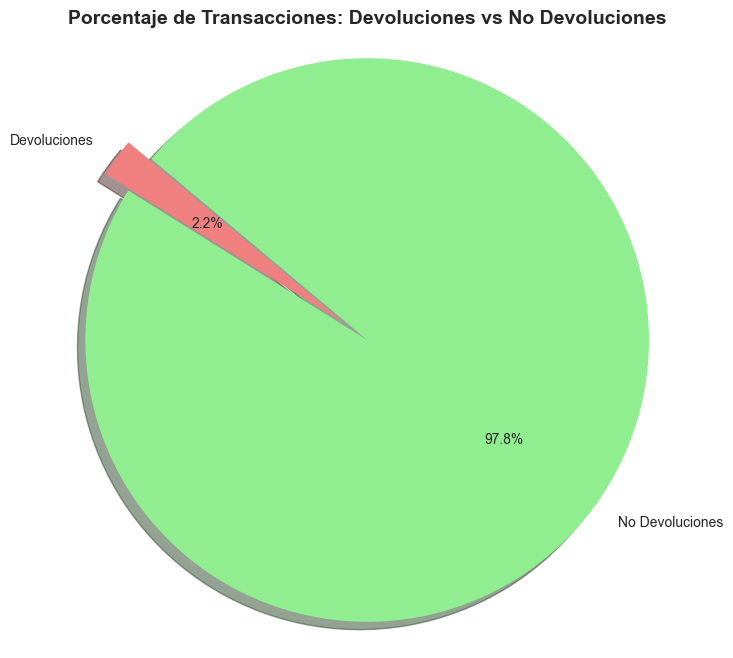

📊 Insight: El porcentaje de devoluciones es bajo (< 10%), lo cual es saludable.


In [111]:
# Datos para el gráfico
labels = ['Devoluciones', 'No Devoluciones']
sizes = [total_returns, total_non_returns]
colors = ['lightcoral', 'lightgreen']
explode = (0.1, 0)  # "Explotar" la primera porción

# Crear gráfico
plt.figure(figsize=(8, 8))
plt.pie(sizes,
        explode=explode,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=140,
        shadow=True)

plt.title('Porcentaje de Transacciones: Devoluciones vs No Devoluciones',
          fontsize=14, fontweight='bold')
plt.axis('equal')  # Para que sea un círculo perfecto
plt.show()

print("📊 Insight: ", end="")
if pct_returns < 10:
    print("El porcentaje de devoluciones es bajo (< 10%), lo cual es saludable.")
elif pct_returns < 20:
    print("El porcentaje de devoluciones es moderado (10-20%), requiere atención.")
else:
    print("El porcentaje de devoluciones es alto (> 20%), acción urgente necesaria.")

### Visualización 2: Distribución por Categoría de Monto

**Pregunta de negocio:** ¿La mayoría de nuestros clientes hacen compras pequeñas, medianas o grandes?

**Implicación:**
- Muchos "Low" → Estrategia de volumen
- Muchos "High" → Estrategia premium
- Balanceado → Estrategia mixta

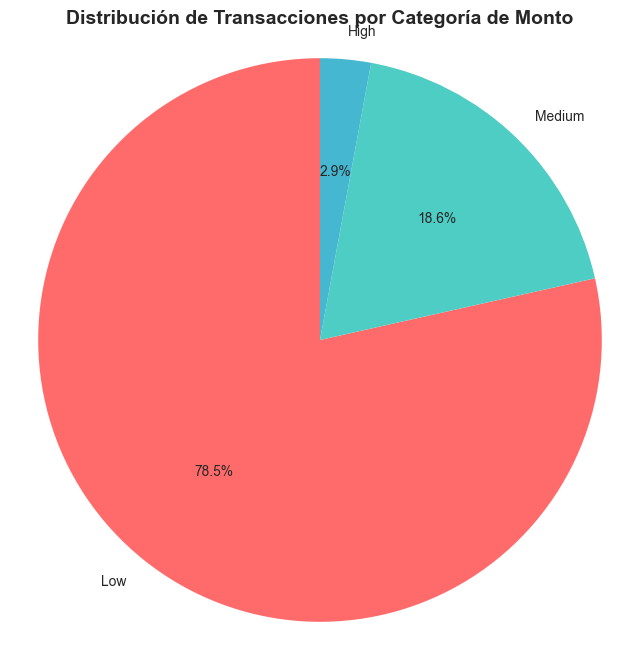

📊 Insight: La categoría dominante es 'Low' con 78.5%


In [112]:
# Contar por categoría
category_counts = data_cleaned['Amount_Category'].value_counts()

# Crear gráfico
plt.figure(figsize=(8, 8))
plt.pie(category_counts.values,
        labels=category_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])

plt.title('Distribución de Transacciones por Categoría de Monto',
          fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

# Análisis automático
categoria_dominante = category_counts.idxmax()
pct_dominante = (category_counts.max() / category_counts.sum()) * 100

print(f"📊 Insight: La categoría dominante es '{categoria_dominante}' con {pct_dominante:.1f}%")

### Visualización 3: Ventas Mensuales por Año

**Tipo:** Gráfico de barras verticales

**¿Por qué bar chart?**
- Excelente para comparar valores entre categorías
- Muestra tendencias temporales claramente
- Identifica picos y valles de ventas

**Pregunta de negocio:** ¿En qué meses vendemos más? ¿Hay estacionalidad?

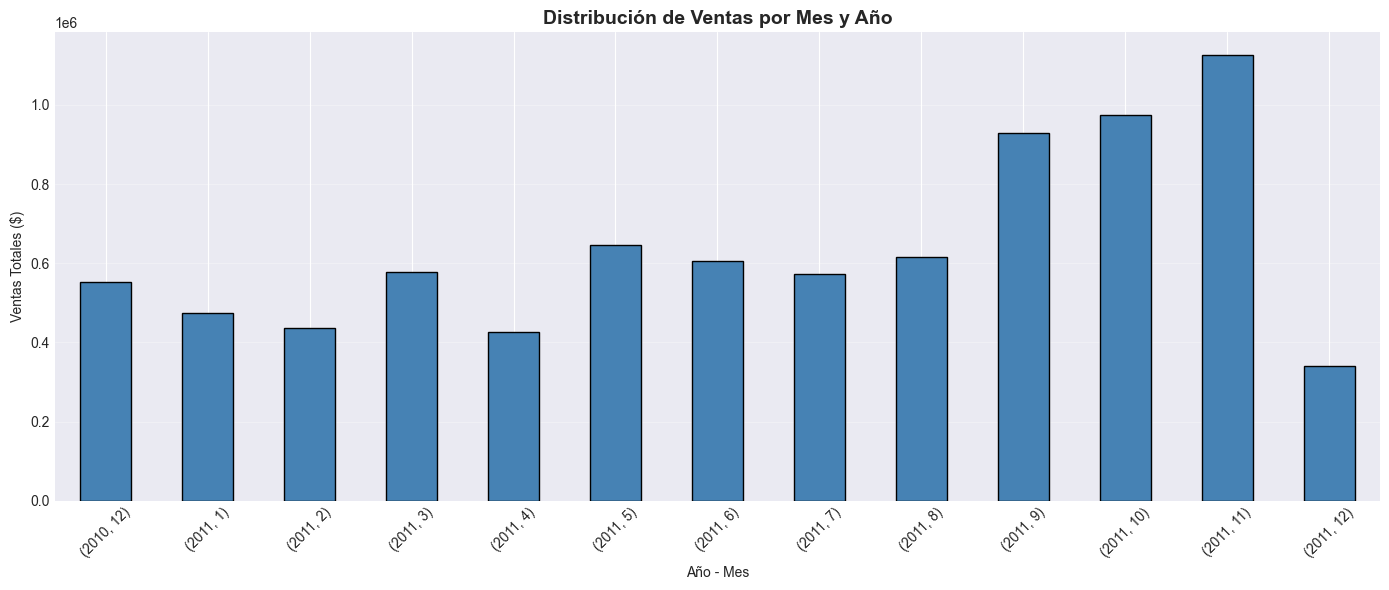

📊 Mes con mayores ventas: 11/2011 con $1,126,815.07
📊 Mes con menores ventas: 12/2011 con $341,539.43


In [115]:
# Agrupar ventas por año y mes
monthly_sales = data_cleaned.groupby(['Year', 'Month'])['Total_Amount'].sum()

# Crear gráfico
plt.figure(figsize=(14, 6))
monthly_sales.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Distribución de Ventas por Mes y Año', fontsize=14, fontweight='bold')
plt.xlabel('Año - Mes')
plt.ylabel('Ventas Totales ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Identificar el mes con mayores ventas
mes_max = monthly_sales.idxmax()
ventas_max = monthly_sales.max()
# Desempaquetar la tupla
year_max, month_max = mes_max
print(f"📊 Mes con mayores ventas: {month_max:02d}/{year_max} con ${ventas_max:,.2f}")


# Identificar el mes con menores ventas
mes_min = monthly_sales.idxmin()
ventas_min = monthly_sales.min()
year_min, month_min = mes_min
print(f"📊 Mes con menores ventas: {month_min:02d}/{year_min} con ${ventas_min:,.2f}")


### Análisis de Estacionalidad

**Insight automático:** Analicemos si hay un patrón estacional evidente.

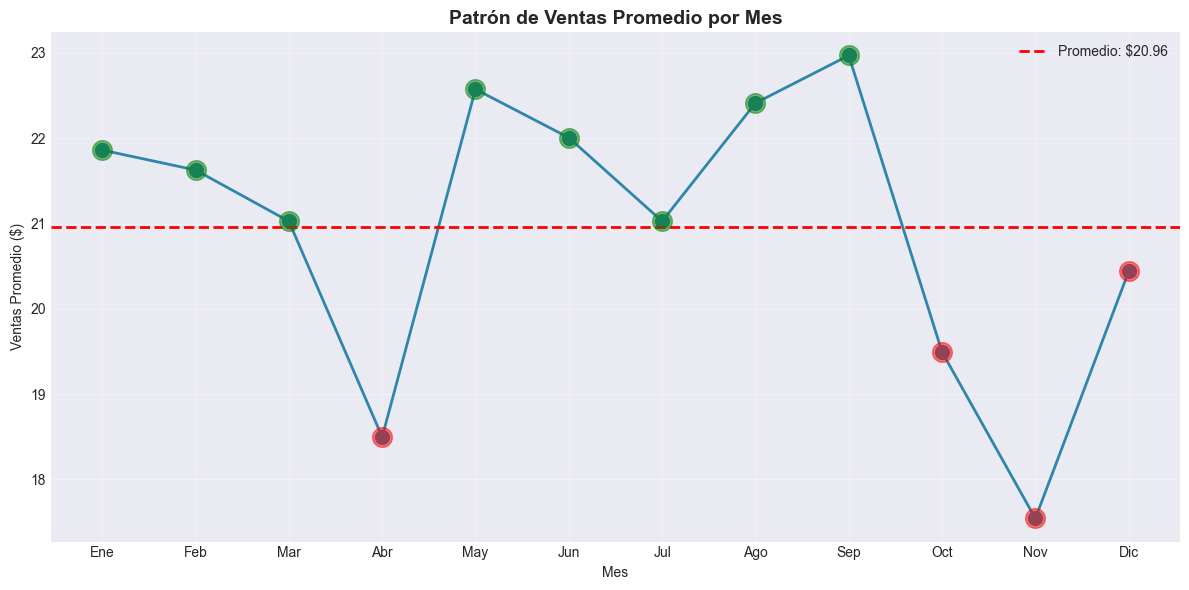

📈 Meses con ventas por encima del promedio: [1, 2, 3, 5, 6, 7, 8, 9]


In [118]:
# Promedio de ventas por mes (agregado de todos los años)
ventas_por_mes = data_cleaned.groupby('Month')['Total_Amount'].mean()

plt.figure(figsize=(12, 6))
plt.plot(ventas_por_mes.index, ventas_por_mes.values,
         marker='o', linewidth=2, markersize=10, color='#2E86AB')

# Añadir línea de promedio general
promedio_general = ventas_por_mes.mean()
plt.axhline(y=promedio_general, color='red', linestyle='--',
            linewidth=2, label=f'Promedio: ${promedio_general:,.2f}')

# Marcar meses por encima/debajo del promedio
for mes, venta in ventas_por_mes.items():
    if venta > promedio_general:
        plt.scatter(mes, venta, color='green', s=200, alpha=0.5, zorder=3)
    else:
        plt.scatter(mes, venta, color='red', s=200, alpha=0.5, zorder=3)

plt.title('Patrón de Ventas Promedio por Mes', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Ventas Promedio ($)')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identificar meses fuertes
meses_fuertes = ventas_por_mes[ventas_por_mes > promedio_general]
print(f"📈 Meses con ventas por encima del promedio: {list(meses_fuertes.index)}")

C:\Users\hamtr\AppData\Local\Temp\ipykernel_17020\339661226.py:140: UserWarning: Glyph 8599 (\N{NORTH EAST ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hamtr\AppData\Local\Temp\ipykernel_17020\339661226.py:140: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hamtr\AppData\Local\Temp\ipykernel_17020\339661226.py:140: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
D:\01_Git\mi_primer_proyecto\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8599 (\N{NORTH EAST ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\01_Git\mi_primer_proyecto\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\01_Git\mi_primer_proyecto\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

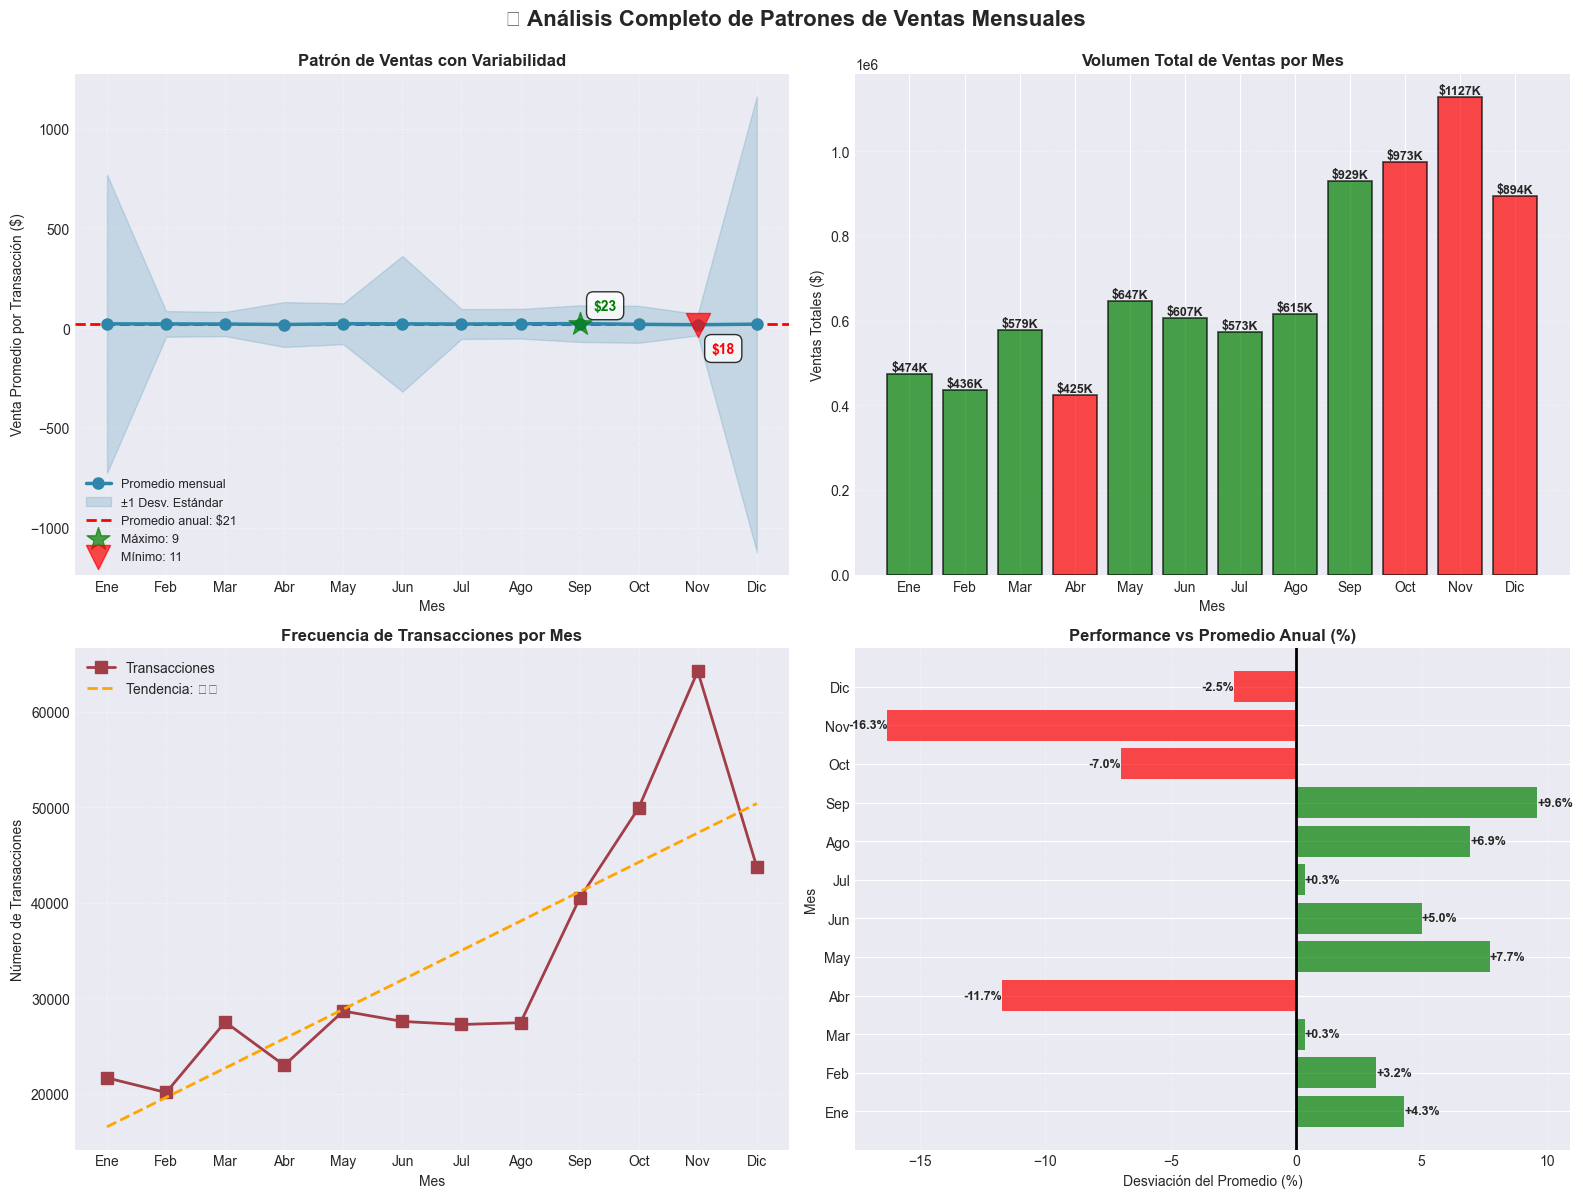

📊 INSIGHTS CLAVE DEL ANÁLISIS MENSUAL

💪 MESES FUERTES (8):
   • Enero: $22 (+4.3%)
   • Febrero: $22 (+3.2%)
   • Marzo: $21 (+0.3%)
   • Mayo: $23 (+7.7%)
   • Junio: $22 (+5.0%)
   • Julio: $21 (+0.3%)
   • Agosto: $22 (+6.9%)
   • Septiembre: $23 (+9.6%)

📉 MESES DÉBILES (4):
   • Abril: $18 (-11.7%)
   • Octubre: $19 (-7.0%)
   • Noviembre: $18 (-16.3%)
   • Diciembre: $20 (-2.5%)

🌡️ ANÁLISIS DE ESTACIONALIDAD:
   🏆 Mejor trimestre: Q3 (Jul-Sep) ($22)

📊 CONSISTENCIA:
   ✅ Mes más consistente: Noviembre
   ⚠️ Mes más variable: Diciembre

💡 OPORTUNIDADES:
   • Brecha entre mejor y peor mes: $5 (30.9%)
   • Si Noviembre alcanzara el promedio: +$219,274
   • Total de meses bajo el promedio: 4 (33%)

🎯 RECOMENDACIONES:
   1. Enfoque en meses débiles: Abril, Octubre, Noviembre
   2. Replicar estrategias de: Septiembre
   3. Preparar inventario para: Q3 (Jul-Sep)


In [123]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular métricas adicionales
ventas_por_mes = data_cleaned.groupby('Month')['Total_Amount'].agg(['mean', 'sum', 'count', 'std'])
promedio_general = ventas_por_mes['mean'].mean()

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📊 Análisis Completo de Patrones de Ventas Mensuales',
             fontsize=16, fontweight='bold', y=0.995)

# ============================================================
# GRÁFICO 1: Patrón de Ventas con Estadísticas
# ============================================================
ax1 = axes[0, 0]

# Línea principal
ax1.plot(ventas_por_mes.index, ventas_por_mes['mean'],
         marker='o', linewidth=2.5, markersize=8, color='#2E86AB',
         label='Promedio mensual', zorder=5)

# Banda de desviación estándar (muestra variabilidad)
ax1.fill_between(ventas_por_mes.index,
                  ventas_por_mes['mean'] - ventas_por_mes['std'],
                  ventas_por_mes['mean'] + ventas_por_mes['std'],
                  alpha=0.2, color='#2E86AB', label='±1 Desv. Estándar')

# Línea de promedio general
ax1.axhline(y=promedio_general, color='red', linestyle='--',
            linewidth=2, label=f'Promedio anual: ${promedio_general:,.0f}', zorder=4)

# Marcar máximos y mínimos
mes_max = ventas_por_mes['mean'].idxmax()
mes_min = ventas_por_mes['mean'].idxmin()
venta_max = ventas_por_mes['mean'].max()
venta_min = ventas_por_mes['mean'].min()

ax1.scatter(mes_max, venta_max, color='green', s=300, alpha=0.7,
            marker='*', zorder=6, label=f'Máximo: {mes_max}')
ax1.scatter(mes_min, venta_min, color='red', s=300, alpha=0.7,
            marker='v', zorder=6, label=f'Mínimo: {mes_min}')

# Anotaciones de valores
ax1.annotate(f'${venta_max:,.0f}', xy=(mes_max, venta_max),
             xytext=(10, 10), textcoords='offset points',
             fontsize=10, fontweight='bold', color='green',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
ax1.annotate(f'${venta_min:,.0f}', xy=(mes_min, venta_min),
             xytext=(10, -20), textcoords='offset points',
             fontsize=10, fontweight='bold', color='red',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

ax1.set_title('Patrón de Ventas con Variabilidad', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mes')
ax1.set_ylabel('Venta Promedio por Transacción ($)')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                     'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')

# ============================================================
# GRÁFICO 2: Volumen de Ventas Totales por Mes
# ============================================================
ax2 = axes[0, 1]

colors = ['green' if x > promedio_general else 'red'
          for x in ventas_por_mes['mean']]

bars = ax2.bar(ventas_por_mes.index, ventas_por_mes['sum'],
               color=colors, alpha=0.7, edgecolor='black', linewidth=1.2)

# Añadir valores sobre las barras
for i, (idx, row) in enumerate(ventas_por_mes.iterrows()):
    ax2.text(idx, row['sum'], f"${row['sum']/1000:.0f}K",
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Volumen Total de Ventas por Mes', fontsize=12, fontweight='bold')
ax2.set_xlabel('Mes')
ax2.set_ylabel('Ventas Totales ($)')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                     'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# ============================================================
# GRÁFICO 3: Número de Transacciones por Mes
# ============================================================
ax3 = axes[1, 0]

ax3.plot(ventas_por_mes.index, ventas_por_mes['count'],
         marker='s', linewidth=2, markersize=8, color='#A23E48',
         label='Transacciones')

# Línea de tendencia
z = np.polyfit(ventas_por_mes.index, ventas_por_mes['count'], 1)
p = np.poly1d(z)
ax3.plot(ventas_por_mes.index, p(ventas_por_mes.index),
         linestyle='--', color='orange', linewidth=2,
         label=f'Tendencia: {"↗️" if z[0] > 0 else "↘️"}')

ax3.set_title('Frecuencia de Transacciones por Mes', fontsize=12, fontweight='bold')
ax3.set_xlabel('Mes')
ax3.set_ylabel('Número de Transacciones')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                     'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3, linestyle='--')

# ============================================================
# GRÁFICO 4: Heatmap de Performance
# ============================================================
ax4 = axes[1, 1]

# Calcular % sobre/bajo el promedio
performance = ((ventas_por_mes['mean'] - promedio_general) / promedio_general) * 100

colors_perf = ['green' if x > 0 else 'red' for x in performance]
bars = ax4.barh(ventas_por_mes.index, performance, color=colors_perf, alpha=0.7)

# Añadir línea de referencia en 0
ax4.axvline(x=0, color='black', linewidth=2)

# Añadir valores
for i, (idx, val) in enumerate(performance.items()):
    ax4.text(val, idx, f'{val:+.1f}%',
             ha='left' if val > 0 else 'right',
             va='center', fontsize=9, fontweight='bold')

ax4.set_title('Performance vs Promedio Anual (%)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Desviación del Promedio (%)')
ax4.set_ylabel('Mes')
ax4.set_yticks(range(1, 13))
ax4.set_yticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                     'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
ax4.grid(True, alpha=0.3, axis='x', linestyle='--')

plt.tight_layout()
plt.show()

# ============================================================
# INSIGHTS TEXTUALES
# ============================================================
print("="*70)
print("📊 INSIGHTS CLAVE DEL ANÁLISIS MENSUAL")
print("="*70)

# 1. Meses fuertes vs débiles
meses_fuertes = ventas_por_mes[ventas_por_mes['mean'] > promedio_general]
meses_debiles = ventas_por_mes[ventas_por_mes['mean'] <= promedio_general]

meses_nombres = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
                 5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
                 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}

print(f"\n💪 MESES FUERTES ({len(meses_fuertes)}):")
for mes in meses_fuertes.index:
    pct = ((ventas_por_mes.loc[mes, 'mean'] - promedio_general) / promedio_general) * 100
    print(f"   • {meses_nombres[mes]}: ${ventas_por_mes.loc[mes, 'mean']:,.0f} (+{pct:.1f}%)")

print(f"\n📉 MESES DÉBILES ({len(meses_debiles)}):")
for mes in meses_debiles.index:
    pct = ((ventas_por_mes.loc[mes, 'mean'] - promedio_general) / promedio_general) * 100
    print(f"   • {meses_nombres[mes]}: ${ventas_por_mes.loc[mes, 'mean']:,.0f} ({pct:.1f}%)")

# 2. Estacionalidad
print(f"\n🌡️ ANÁLISIS DE ESTACIONALIDAD:")
q1 = ventas_por_mes.loc[1:3, 'mean'].mean()
q2 = ventas_por_mes.loc[4:6, 'mean'].mean()
q3 = ventas_por_mes.loc[7:9, 'mean'].mean()
q4 = ventas_por_mes.loc[10:12, 'mean'].mean()

trimestres = {'Q1 (Ene-Mar)': q1, 'Q2 (Abr-Jun)': q2,
              'Q3 (Jul-Sep)': q3, 'Q4 (Oct-Dic)': q4}
mejor_trimestre = max(trimestres, key=trimestres.get)
print(f"   🏆 Mejor trimestre: {mejor_trimestre} (${trimestres[mejor_trimestre]:,.0f})")

# 3. Variabilidad
mes_mas_consistente = ventas_por_mes['std'].idxmin()
mes_mas_variable = ventas_por_mes['std'].idxmax()
print(f"\n📊 CONSISTENCIA:")
print(f"   ✅ Mes más consistente: {meses_nombres[mes_mas_consistente]}")
print(f"   ⚠️ Mes más variable: {meses_nombres[mes_mas_variable]}")

# 4. Oportunidades
diferencia_max_min = venta_max - venta_min
print(f"\n💡 OPORTUNIDADES:")
print(f"   • Brecha entre mejor y peor mes: ${diferencia_max_min:,.0f} ({(diferencia_max_min/venta_min)*100:.1f}%)")
print(f"   • Si {meses_nombres[mes_min]} alcanzara el promedio: +${(promedio_general - venta_min) * ventas_por_mes.loc[mes_min, 'count']:,.0f}")
print(f"   • Total de meses bajo el promedio: {len(meses_debiles)} ({len(meses_debiles)/12*100:.0f}%)")

# 5. Recomendaciones
print(f"\n🎯 RECOMENDACIONES:")
print(f"   1. Enfoque en meses débiles: {', '.join([meses_nombres[m] for m in meses_debiles.index[:3]])}")
print(f"   2. Replicar estrategias de: {meses_nombres[mes_max]}")
print(f"   3. Preparar inventario para: {mejor_trimestre}")

C:\Users\hamtr\AppData\Local\Temp\ipykernel_17020\2297156961.py:82: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
D:\01_Git\mi_primer_proyecto\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


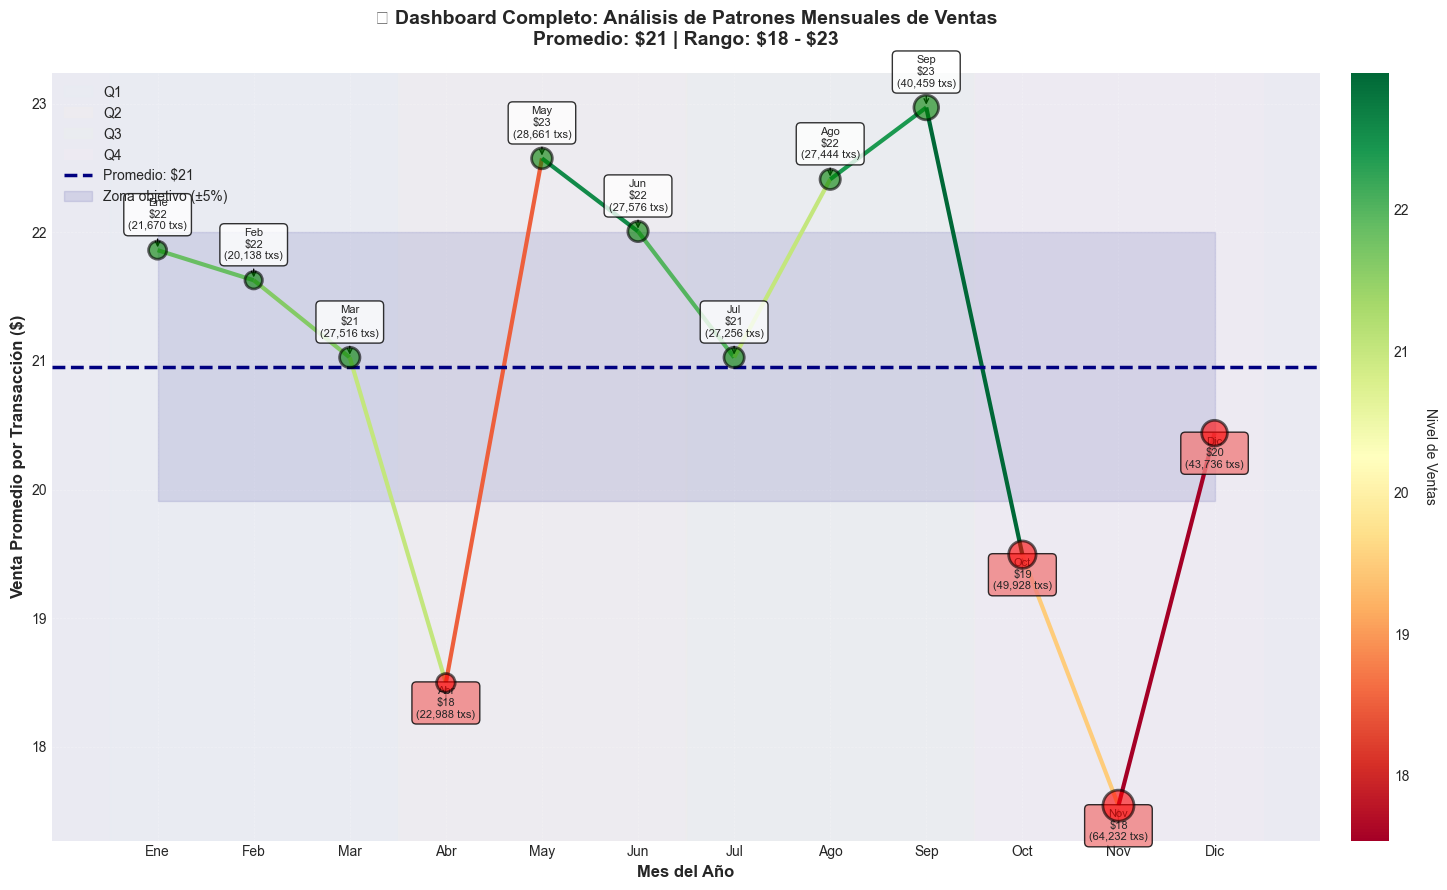


🔬 ANÁLISIS ESTADÍSTICO AVANZADO:

📊 Coeficiente de Variación por mes:
   • Diciembre: 5587.1% (alta variabilidad)
   • Enero: 3422.0% (alta variabilidad)
   • Junio: 1544.7% (alta variabilidad)

🌡️ Índice de Estacionalidad:
   • Septiembre: 109.6 puntos
   • Mayo: 107.7 puntos
   • Agosto: 106.9 puntos

🔗 Correlación volumen-valor: -0.56


In [122]:
# Crear gráfico único pero MUY informativo
fig, ax = plt.subplots(figsize=(16, 9))

# Datos
ventas_por_mes = data_cleaned.groupby('Month')['Total_Amount'].agg(['mean', 'count', 'std'])
promedio_general = ventas_por_mes['mean'].mean()

# Background por trimestre
trimestres = [(1, 'Q1', '#E8F4F8'), (4, 'Q2', '#FFF4E6'),
              (7, 'Q3', '#F0F8E8'), (10, 'Q4', '#FFF0F5')]
for inicio, nombre, color in trimestres:
    ax.axvspan(inicio-0.5, inicio+2.5, alpha=0.15, color=color, label=nombre)

# Línea principal con gradiente
x = ventas_por_mes.index
y = ventas_por_mes['mean']
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

from matplotlib.collections import LineCollection
norm = plt.Normalize(y.min(), y.max())
lc = LineCollection(segments, cmap='RdYlGn', norm=norm, linewidth=3)
lc.set_array(y)
line = ax.add_collection(lc)

# Puntos con tamaño según volumen de transacciones
sizes = (ventas_por_mes['count'] / ventas_por_mes['count'].max()) * 500
colors_scatter = ['green' if v > promedio_general else 'red' for v in y]
ax.scatter(x, y, s=sizes, c=colors_scatter, alpha=0.6, edgecolors='black', linewidth=2, zorder=5)

# Promedio con zona de confort
ax.axhline(y=promedio_general, color='navy', linestyle='--', linewidth=2.5,
           label=f'Promedio: ${promedio_general:,.0f}', zorder=4)
ax.fill_between(range(1, 13), promedio_general*0.95, promedio_general*1.05,
                alpha=0.1, color='navy', label='Zona objetivo (±5%)')

# Anotaciones detalladas para cada mes
meses_nombres_cortos = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                        'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
for mes, nombre in zip(ventas_por_mes.index, meses_nombres_cortos):
    valor = ventas_por_mes.loc[mes, 'mean']
    transacciones = ventas_por_mes.loc[mes, 'count']

    # Calcular posición de texto
    offset = 15 if valor > promedio_general else -25

    ax.annotate(f'{nombre}\n${valor:,.0f}\n({transacciones:,} txs)',
                xy=(mes, valor),
                xytext=(0, offset),
                textcoords='offset points',
                ha='center',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.4',
                         facecolor='white' if valor > promedio_general else 'lightcoral',
                         alpha=0.8, edgecolor='black'),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))

# Títulos y etiquetas
ax.set_title('📊 Dashboard Completo: Análisis de Patrones Mensuales de Ventas\n' +
             f'Promedio: ${promedio_general:,.0f} | Rango: ${y.min():,.0f} - ${y.max():,.0f}',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Mes del Año', fontsize=12, fontweight='bold')
ax.set_ylabel('Venta Promedio por Transacción ($)', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nombres_cortos)

# Leyenda personalizada
handles, labels = ax.get_legend_handles_labels()
# Remover duplicados de trimestres
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left',
          fontsize=10, framealpha=0.9)

# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Colorbar para la línea
cbar = fig.colorbar(line, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Nivel de Ventas', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

# Análisis avanzado
print("\n🔬 ANÁLISIS ESTADÍSTICO AVANZADO:")

# Coeficiente de variación
cv = (ventas_por_mes['std'] / ventas_por_mes['mean']) * 100
print(f"\n📊 Coeficiente de Variación por mes:")
for mes in cv.nlargest(3).index:
    print(f"   • {meses_nombres[mes]}: {cv[mes]:.1f}% (alta variabilidad)")

# Índice de estacionalidad
indice_estacional = (ventas_por_mes['mean'] / promedio_general) * 100
print(f"\n🌡️ Índice de Estacionalidad:")
for mes in indice_estacional.nlargest(3).index:
    print(f"   • {meses_nombres[mes]}: {indice_estacional[mes]:.1f} puntos")

# Correlación entre volumen y valor
correlacion = ventas_por_mes['count'].corr(ventas_por_mes['mean'])
print(f"\n🔗 Correlación volumen-valor: {correlacion:.2f}")
if abs(correlacion) < 0.3:
    print("   → Ventas altas NO necesariamente = más transacciones")
elif correlacion > 0.7:
    print("   → Más transacciones = Mayores ventas promedio")

### Visualización 4: Top 10 Productos Más Vendidos

**Tipo:** Gráfico de barras horizontales

**¿Por qué horizontal?**
- Mejor para etiquetas largas (nombres de productos)
- Fácil de leer de arriba a abajo (ranking)
- Orden descendente intuitivo

**Pregunta de negocio:** ¿Cuáles son nuestros productos estrella?

**Consideración técnica:**
- Agrupamos por `StockCode` (código único del producto)
- Sumamos `Quantity` (cantidad total vendida)
- Hacemos merge con `Description` para mostrar nombres

In [124]:
# Paso 1: Agrupar y sumar cantidades por producto
top_productos = data_cleaned.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)

# Paso 2: Convertir a DataFrame para facilitar el merge
top_productos = top_productos.reset_index()

# Paso 3: Obtener las descripciones de productos (sin duplicados)
descripciones = data_cleaned[['StockCode', 'Description']].drop_duplicates()

# Paso 4: Merge para añadir descripciones
top_productos = pd.merge(top_productos, descripciones, on='StockCode', how='left')

# Mostrar el top 10
print("📊 Top 10 Productos Más Vendidos:\n")
for i, row in top_productos.iterrows():
    print(f"{i+1}. {row['Description']}: {row['Quantity']:,} unidades")

📊 Top 10 Productos Más Vendidos:

1. WORLD WAR 2 GLIDERS ASSTD DESIGNS: 53,119 unidades
2. SMALL POPCORN HOLDER: 48,689 unidades
3. POPCORN HOLDER: 48,689 unidades
4. JUMBO BAG RED RETROSPOT: 44,963 unidades
5. ASSORTED COLOUR BIRD ORNAMENT: 35,215 unidades
6. WHITE HANGING HEART T-LIGHT HOLDER: 34,185 unidades
7. CREAM HANGING HEART T-LIGHT HOLDER: 34,185 unidades
8. PACK OF 72 RETROSPOT CAKE CASES: 33,386 unidades
9. RABBIT NIGHT LIGHT: 27,045 unidades
10. MINI PAINT SET VINTAGE : 25,880 unidades
11. PACK OF 12 LONDON TISSUES : 25,305 unidades
12. PACK OF 60 PINK PAISLEY CAKE CASES: 24,129 unidades


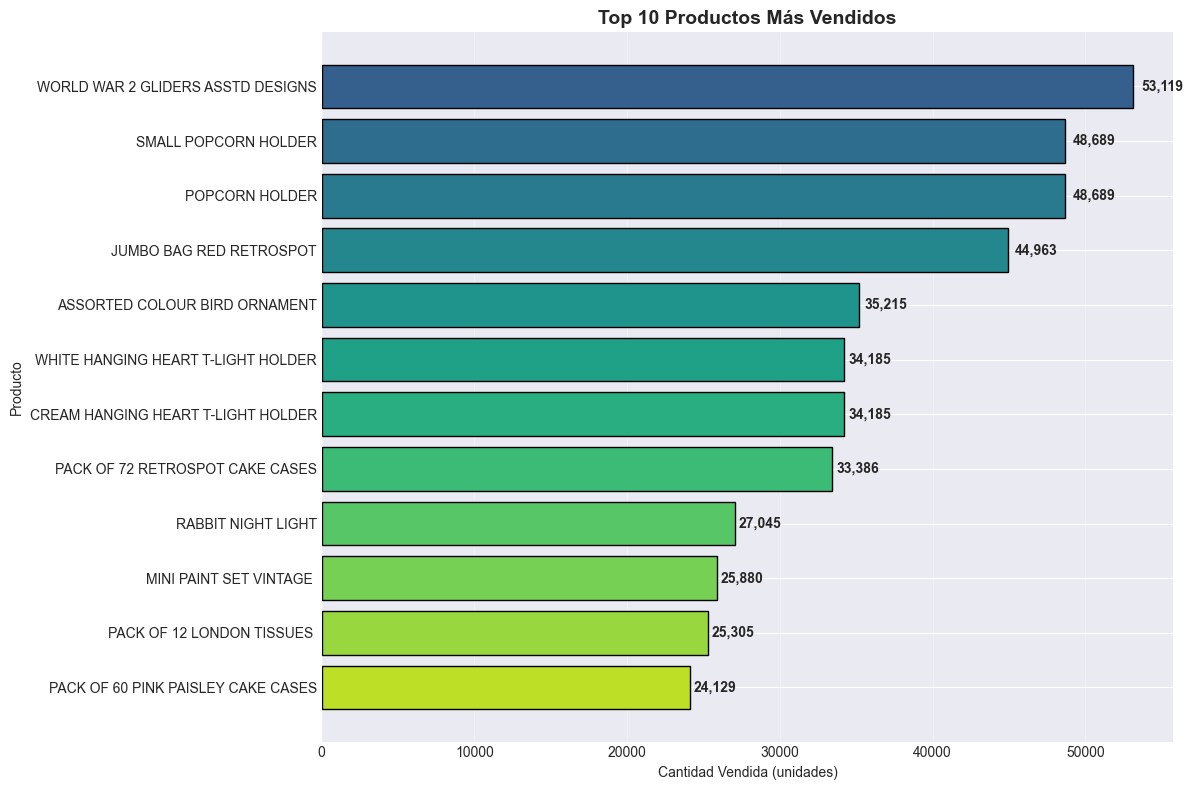

In [125]:
# Crear visualización
plt.figure(figsize=(12, 8))

# Colores degradados
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_productos)))

plt.barh(top_productos['Description'], top_productos['Quantity'], color=colors, edgecolor='black')

plt.title('Top 10 Productos Más Vendidos', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad Vendida (unidades)')
plt.ylabel('Producto')

# Invertir eje Y para que el #1 esté arriba
plt.gca().invert_yaxis()

# Añadir valores al final de cada barra
for i, (desc, qty) in enumerate(zip(top_productos['Description'], top_productos['Quantity'])):
    plt.text(qty + (qty * 0.01), i, f'{qty:,}',
             va='center', fontsize=10, fontweight='bold')

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 6️⃣ FASE 6: Dashboard Ejecutivo Consolidado

### ¿Por qué un dashboard?

En el mundo real, los científicos de datos deben **comunicar insights** a stakeholders no técnicos.

Un dashboard efectivo:
- Resume información compleja visualmente
- Permite tomar decisiones rápidas
- Se puede automatizar y actualizar periódicamente
- Es presentable en reuniones ejecutivas

Crearemos un **dashboard de 4 cuadrantes** con GridSpec mostrando:
1. Devoluciones (Pie Chart)
2. Categorías de Monto (Pie Chart)
3. Ventas Mensuales (Bar Chart)
4. Top 5 Productos (Horizontal Bar)

C:\Users\hamtr\AppData\Local\Temp\ipykernel_17020\3761030829.py:65: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
D:\01_Git\mi_primer_proyecto\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


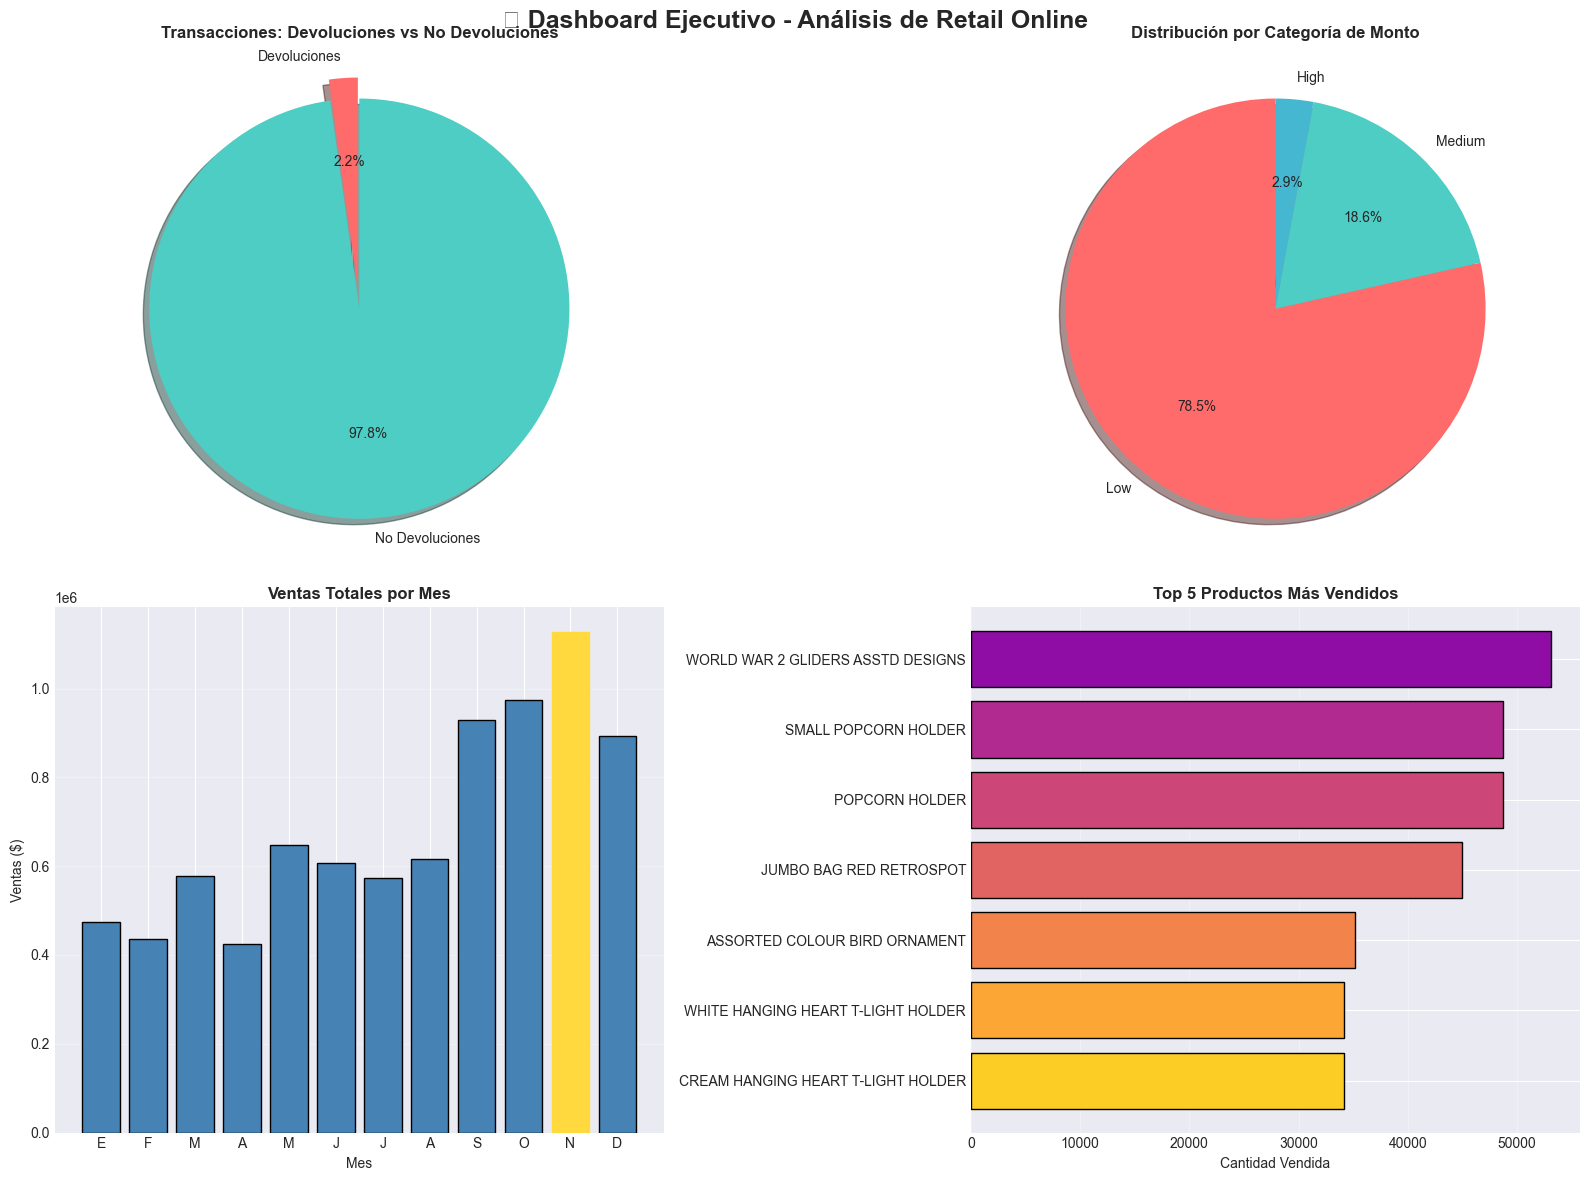

✅ Dashboard ejecutivo generado exitosamente


In [126]:
import matplotlib.gridspec as gridspec

# Preparar datos para el dashboard
top_5_productos = data_cleaned.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(5)
top_5_productos = top_5_productos.reset_index()
top_5_productos = pd.merge(top_5_productos, descripciones, on='StockCode', how='left')

# Crear figura con GridSpec
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])
fig = plt.figure(figsize=(16, 12))
fig.suptitle('📊 Dashboard Ejecutivo - Análisis de Retail Online',
             fontsize=18, fontweight='bold', y=0.98)

# ========== Cuadrante 1: Devoluciones ==========
ax1 = fig.add_subplot(gs[0, 0])
labels_dev = ['Devoluciones', 'No Devoluciones']
sizes_dev = [total_returns, total_non_returns]
colors_dev = ['#FF6B6B', '#4ECDC4']
explode_dev = (0.1, 0)

ax1.pie(sizes_dev, explode=explode_dev, labels=labels_dev, colors=colors_dev,
        autopct='%1.1f%%', startangle=90, shadow=True)
ax1.set_title('Transacciones: Devoluciones vs No Devoluciones',
              fontsize=12, fontweight='bold')

# ========== Cuadrante 2: Categorías de Monto ==========
ax2 = fig.add_subplot(gs[0, 1])
category_counts = data_cleaned['Amount_Category'].value_counts()
colors_cat = ['#FF6B6B', '#4ECDC4', '#45B7D1']

ax2.pie(category_counts.values, labels=category_counts.index, colors=colors_cat,
        autopct='%1.1f%%', startangle=90, shadow=True)
ax2.set_title('Distribución por Categoría de Monto',
              fontsize=12, fontweight='bold')

# ========== Cuadrante 3: Ventas Mensuales ==========
ax3 = fig.add_subplot(gs[1, 0])
monthly_sales_simple = data_cleaned.groupby('Month')['Total_Amount'].sum()
bars = ax3.bar(monthly_sales_simple.index, monthly_sales_simple.values,
               color='steelblue', edgecolor='black')

# Colorear la barra del mes con mayor venta
max_idx = monthly_sales_simple.idxmax()
bars[max_idx-1].set_color('#FFD93D')

ax3.set_title('Ventas Totales por Mes', fontsize=12, fontweight='bold')
ax3.set_xlabel('Mes')
ax3.set_ylabel('Ventas ($)')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(['E', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax3.grid(True, alpha=0.3, axis='y')

# ========== Cuadrante 4: Top 5 Productos ==========
ax4 = fig.add_subplot(gs[1, 1])
colors_prod = plt.cm.plasma(np.linspace(0.3, 0.9, len(top_5_productos)))

ax4.barh(top_5_productos['Description'], top_5_productos['Quantity'],
         color=colors_prod, edgecolor='black')
ax4.set_title('Top 5 Productos Más Vendidos', fontsize=12, fontweight='bold')
ax4.set_xlabel('Cantidad Vendida')
ax4.invert_yaxis()
ax4.grid(True, alpha=0.3, axis='x')

# Ajustar espaciado
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

print("✅ Dashboard ejecutivo generado exitosamente")

C:\Users\hamtr\AppData\Local\Temp\ipykernel_17020\49219395.py:334: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\hamtr\AppData\Local\Temp\ipykernel_17020\49219395.py:335: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.savefig('dashboard_ejecutivo_mejorado.png', dpi=300, bbox_inches='tight')
C:\Users\hamtr\AppData\Local\Temp\ipykernel_17020\49219395.py:335: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('dashboard_ejecutivo_mejorado.png', dpi=300, bbox_inches='tight')
C:\Users\hamtr\AppData\Local\Temp\ipykernel_17020\49219395.py:335: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.savefig('dashboard_ejecutivo_mejorado.png', dpi=300, bbox_inches='tight')
C:\Users\hamtr\AppData\Local\Temp\ipykernel_17020\49219395.py:335: UserWar

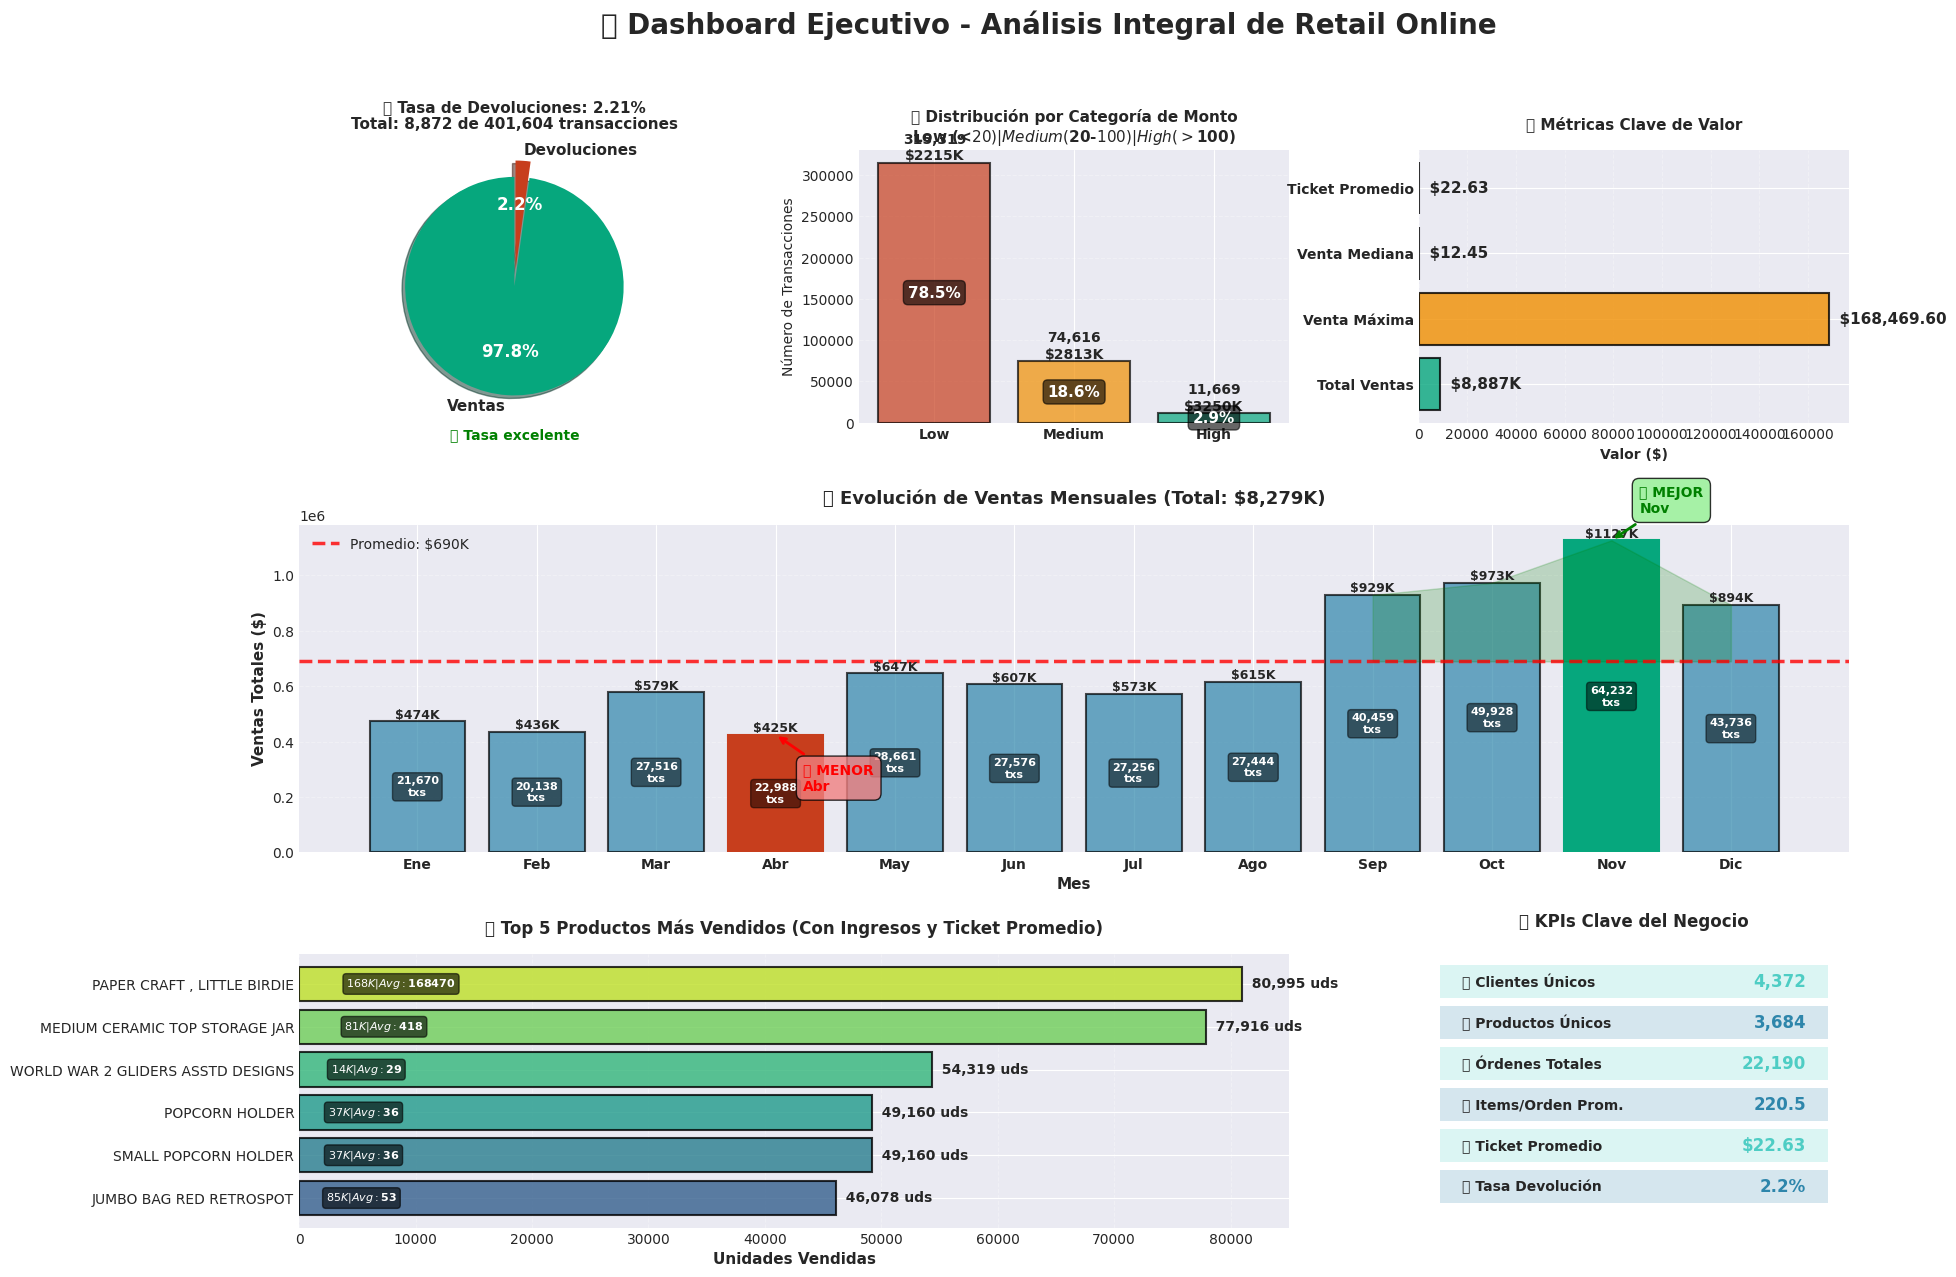

📊 RESUMEN EJECUTIVO - INSIGHTS CLAVE

💰 MÉTRICAS DE VENTAS:
   • Ventas totales: $8,887,208.89
   • Ticket promedio: $22.63
   • Venta mediana: $12.45
   • Mayor venta individual: $168,469.60

🔄 ANÁLISIS DE DEVOLUCIONES:
   • Tasa de devolución: 2.21%

📅 MEJOR Y PEOR MES:
   🏆 Mejor: Noviembre - $1,126,815.07
   📉 Peor: Abril - $425,222.67
   • Brecha: $701,592.40 (165.0%)

🏆 TOP PRODUCTO:
   • PAPER CRAFT , LITTLE BIRDIE
   • Unidades vendidas: 80,995
   • Ingresos generados: $168,469.60
   • Órdenes: 1

💡 RECOMENDACIONES:
   2. 📈 Impulsar ventas de tickets más altos - Cross-selling
   3. 📊 Alta variabilidad mensual - Estabilizar con promociones

✅ Dashboard ejecutivo generado exitosamente


In [133]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from matplotlib import font_manager

# Configurar fuente al inicio del código
plt.rcParams['font.family'] = 'DejaVu Sans'  # Fuente alternativa

# O usar Segoe UI Emoji en Windows
plt.rcParams['font.sans-serif'] = ['Segoe UI Emoji', 'Arial', 'DejaVu Sans']

# ============================================================
# PREPARACIÓN DE DATOS
# ============================================================

# 1. Datos de devoluciones
total_returns = (data_cleaned['Quantity'] < 0).sum()
total_non_returns = (data_cleaned['Quantity'] >= 0).sum()
tasa_devolucion = (total_returns / len(data_cleaned)) * 100

# 2. Top productos (con más contexto)
top_productos = data_cleaned[data_cleaned['Quantity'] > 0].groupby('StockCode').agg({
    'Quantity': 'sum',
    'Total_Amount': 'sum',
    'InvoiceNo': 'nunique'  # Número de órdenes
}).sort_values('Quantity', ascending=False).head(5)
top_productos = pd.merge(top_productos, descripciones, on='StockCode', how='left')
top_productos['Ticket_Promedio'] = top_productos['Total_Amount'] / top_productos['InvoiceNo']

# 3. Ventas mensuales con más detalle
monthly_data = data_cleaned.groupby('Month').agg({
    'Total_Amount': ['sum', 'mean', 'count'],
    'Quantity': 'sum'
})
monthly_data.columns = ['Ventas_Total', 'Ticket_Promedio', 'Num_Transacciones', 'Unidades_Vendidas']

# 4. Categorías de monto con análisis
category_stats = data_cleaned.groupby('Amount_Category').agg({
    'Total_Amount': ['sum', 'mean', 'count']
})
category_stats.columns = ['Total', 'Promedio', 'Cantidad']
category_order = ['Low', 'Medium', 'High']
category_stats = category_stats.reindex(category_order)

# ============================================================
# CREAR DASHBOARD
# ============================================================

# Configuración de colores profesionales
colors_palette = {
    'primary': '#2E86AB',
    'secondary': '#A23E48',
    'success': '#06A77D',
    'warning': '#F18F01',
    'danger': '#C73E1D',
    'info': '#4ECDC4'
}

# Crear figura con GridSpec personalizado
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1.2, 1], width_ratios=[1, 1, 1],
                       hspace=0.35, wspace=0.3)

fig.suptitle('📊 Dashboard Ejecutivo - Análisis Integral de Retail Online',
             fontsize=20, fontweight='bold', y=0.98)

# ============================================================
# CUADRANTE 1: ANÁLISIS DE DEVOLUCIONES (Mejorado)
# ============================================================
ax1 = fig.add_subplot(gs[0, 0])

labels_dev = ['Ventas', 'Devoluciones']
sizes_dev = [total_non_returns, total_returns]
colors_dev = [colors_palette['success'], colors_palette['danger']]
explode_dev = (0, 0.15)

wedges, texts, autotexts = ax1.pie(sizes_dev, explode=explode_dev, labels=labels_dev,
                                     colors=colors_dev, autopct='%1.1f%%',
                                     startangle=90, shadow=True,
                                     textprops={'fontsize': 11, 'weight': 'bold'})

# Mejorar textos
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)

ax1.set_title(f'🔄 Tasa de Devoluciones: {tasa_devolucion:.2f}%\n' +
              f'Total: {total_returns:,} de {len(data_cleaned):,} transacciones',
              fontsize=11, fontweight='bold', pad=15)

# Agregar texto informativo
if tasa_devolucion > 15:
    ax1.text(0, -1.4, '⚠️ Tasa alta - Requiere atención',
             ha='center', fontsize=10, color='red', weight='bold')
elif tasa_devolucion < 5:
    ax1.text(0, -1.4, '✅ Tasa excelente',
             ha='center', fontsize=10, color='green', weight='bold')

# ============================================================
# CUADRANTE 2: CATEGORÍAS DE MONTO (Mejorado con barras)
# ============================================================
ax2 = fig.add_subplot(gs[0, 1])

categories = category_stats.index
x_pos = np.arange(len(categories))
counts = category_stats['Cantidad'].values
totals = category_stats['Total'].values

# Crear barras con colores según categoría
colors_cat = [colors_palette['danger'], colors_palette['warning'], colors_palette['success']]
bars = ax2.bar(x_pos, counts, color=colors_cat, alpha=0.7, edgecolor='black', linewidth=1.5)

# Añadir valores sobre las barras
for i, (bar, count, total) in enumerate(zip(bars, counts, totals)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{count:,}\n${total/1000:.0f}K',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Añadir porcentaje
    pct = (count / counts.sum()) * 100
    ax2.text(bar.get_x() + bar.get_width()/2., height/2,
             f'{pct:.1f}%',
             ha='center', va='center', fontsize=11, fontweight='bold',
             color='white', bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))

ax2.set_title('💰 Distribución por Categoría de Monto\nLow (<$20) | Medium ($20-$100) | High (>$100)',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('Número de Transacciones')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(categories, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# ============================================================
# CUADRANTE 3: ANÁLISIS DE VALOR (NUEVO)
# ============================================================
ax3 = fig.add_subplot(gs[0, 2])

# Métricas clave
metricas = {
    'Ticket Promedio': data_cleaned[data_cleaned['Total_Amount'] > 0]['Total_Amount'].mean(),
    'Venta Mediana': data_cleaned[data_cleaned['Total_Amount'] > 0]['Total_Amount'].median(),
    'Venta Máxima': data_cleaned[data_cleaned['Total_Amount'] > 0]['Total_Amount'].max(),
    'Total Ventas': data_cleaned[data_cleaned['Total_Amount'] > 0]['Total_Amount'].sum()
}

y_pos = np.arange(len(metricas))
valores = list(metricas.values())
labels_metricas = list(metricas.keys())

# Normalizar para visualización (última métrica está en otra escala)
valores_norm = valores.copy()
valores_norm[3] = valores[3] / 1000  # Convertir a miles

bars = ax3.barh(y_pos, valores_norm, color=[colors_palette['info'], colors_palette['primary'],
                                              colors_palette['warning'], colors_palette['success']],
                alpha=0.8, edgecolor='black', linewidth=1.5)

# Añadir valores
for i, (bar, val) in enumerate(zip(bars, valores)):
    if i < 3:
        texto = f'${val:,.2f}'
    else:
        texto = f'${val/1000:,.0f}K'

    ax3.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'  {texto}',
             va='center', ha='left', fontsize=11, fontweight='bold')

ax3.set_yticks(y_pos)
ax3.set_yticklabels(labels_metricas, fontweight='bold')
ax3.set_xlabel('Valor ($)', fontweight='bold')
ax3.set_title('📈 Métricas Clave de Valor', fontsize=11, fontweight='bold', pad=15)
ax3.invert_yaxis()
ax3.grid(True, alpha=0.3, axis='x', linestyle='--')

# ============================================================
# CUADRANTE 4: VENTAS MENSUALES (Mejorado - Más grande)
# ============================================================
ax4 = fig.add_subplot(gs[1, :])  # Ocupa toda la fila

months = monthly_data.index
ventas = monthly_data['Ventas_Total'].values
promedio_mensual = ventas.mean()

# Crear barras
bars = ax4.bar(months, ventas, color=colors_palette['primary'],
               alpha=0.7, edgecolor='black', linewidth=1.5)

# Colorear barras especiales
max_idx = ventas.argmax()
min_idx = ventas.argmin()
bars[max_idx].set_color(colors_palette['success'])
bars[max_idx].set_alpha(1)
bars[min_idx].set_color(colors_palette['danger'])
bars[min_idx].set_alpha(1)

# Línea de promedio
ax4.axhline(y=promedio_mensual, color='red', linestyle='--', linewidth=2.5,
            label=f'Promedio: ${promedio_mensual/1000:,.0f}K', alpha=0.8)

# Añadir valores sobre las barras
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
for i, (bar, venta, transacciones) in enumerate(zip(bars, ventas, monthly_data['Num_Transacciones'])):
    height = bar.get_height()

    # Valor en K
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'${venta/1000:.0f}K',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Número de transacciones
    ax4.text(bar.get_x() + bar.get_width()/2., height * 0.5,
             f'{transacciones:,}\ntxs',
             ha='center', va='center', fontsize=8,
             color='white', weight='bold',
             bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

# Resaltar mejor y peor mes
ax4.annotate(f'🏆 MEJOR\n{meses_nombres[max_idx]}',
             xy=(months[max_idx], ventas[max_idx]),
             xytext=(20, 20), textcoords='offset points',
             fontsize=10, fontweight='bold', color='green',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.8),
             arrowprops=dict(arrowstyle='->', lw=2, color='green'))

ax4.annotate(f'📉 MENOR\n{meses_nombres[min_idx]}',
             xy=(months[min_idx], ventas[min_idx]),
             xytext=(20, -40), textcoords='offset points',
             fontsize=10, fontweight='bold', color='red',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.8),
             arrowprops=dict(arrowstyle='->', lw=2, color='red'))

ax4.set_title(f'📅 Evolución de Ventas Mensuales (Total: ${ventas.sum()/1000:,.0f}K)',
              fontsize=13, fontweight='bold', pad=15)
ax4.set_xlabel('Mes', fontsize=11, fontweight='bold')
ax4.set_ylabel('Ventas Totales ($)', fontsize=11, fontweight='bold')
ax4.set_xticks(months)
ax4.set_xticklabels(meses_nombres, fontweight='bold')
ax4.legend(loc='upper left', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y', linestyle='--')

# Añadir área sombreada para meses sobre el promedio
ax4.fill_between(months, promedio_mensual, ventas,
                  where=(ventas > promedio_mensual),
                  alpha=0.2, color='green', label='Sobre promedio')

# ============================================================
# CUADRANTE 5: TOP 5 PRODUCTOS (Mejorado)
# ============================================================
ax5 = fig.add_subplot(gs[2, :2])  # Ocupa 2/3 de la fila

# Ordenar y preparar datos
top_productos_sorted = top_productos.sort_values('Quantity', ascending=True)
y_pos = np.arange(len(top_productos_sorted))

# Crear barras horizontales con degradado
colors_prod = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_productos_sorted)))
bars = ax5.barh(y_pos, top_productos_sorted['Quantity'],
                color=colors_prod, alpha=0.8, edgecolor='black', linewidth=1.5)

# Añadir valores y detalles
for i, (bar, row) in enumerate(zip(bars, top_productos_sorted.itertuples())):
    # Cantidad
    ax5.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'  {row.Quantity:,} uds',
             va='center', ha='left', fontsize=10, fontweight='bold')

    # Ventas totales y ticket promedio
    ax5.text(bar.get_width() * 0.05, bar.get_y() + bar.get_height()/2,
             f'${row.Total_Amount/1000:.0f}K | Avg: ${row.Ticket_Promedio:.0f}',
             va='center', ha='left', fontsize=8,
             color='white', weight='bold',
             bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))

# Configurar etiquetas (truncar descripciones largas)
labels_productos = [desc[:40] + '...' if len(desc) > 40 else desc
                    for desc in top_productos_sorted['Description']]
ax5.set_yticks(y_pos)
ax5.set_yticklabels(labels_productos, fontsize=10)
ax5.set_xlabel('Unidades Vendidas', fontsize=11, fontweight='bold')
ax5.set_title('🏆 Top 5 Productos Más Vendidos (Con Ingresos y Ticket Promedio)',
              fontsize=12, fontweight='bold', pad=15)
ax5.grid(True, alpha=0.3, axis='x', linestyle='--')

# ============================================================
# CUADRANTE 6: KPIs RESUMEN (NUEVO)
# ============================================================
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')

# Calcular KPIs
total_clientes = data_cleaned['CustomerID'].nunique()
total_productos = data_cleaned['StockCode'].nunique()
total_ordenes = data_cleaned['InvoiceNo'].nunique()
promedio_items_orden = data_cleaned.groupby('InvoiceNo')['Quantity'].sum().mean()

kpis = [
    ('👥 Clientes Únicos', f'{total_clientes:,}'),
    ('📦 Productos Únicos', f'{total_productos:,}'),
    ('🧾 Órdenes Totales', f'{total_ordenes:,}'),
    ('📊 Items/Orden Prom.', f'{promedio_items_orden:.1f}'),
    ('💵 Ticket Promedio', f'${metricas["Ticket Promedio"]:.2f}'),
    ('🔄 Tasa Devolución', f'{tasa_devolucion:.1f}%')
]

# Dibujar KPIs en cuadrícula
y_start = 0.9
for i, (label, valor) in enumerate(kpis):
    y_pos = y_start - (i * 0.15)

    # Fondo de color
    color_fondo = colors_palette['info'] if i % 2 == 0 else colors_palette['primary']
    rect = plt.Rectangle((0.05, y_pos - 0.06), 0.9, 0.12,
                          facecolor=color_fondo, alpha=0.2,
                          transform=ax6.transAxes, zorder=0)
    ax6.add_patch(rect)

    # Texto
    ax6.text(0.1, y_pos, label, fontsize=10, fontweight='bold',
             transform=ax6.transAxes, va='center')
    ax6.text(0.9, y_pos, valor, fontsize=12, fontweight='bold',
             transform=ax6.transAxes, va='center', ha='right',
             color=color_fondo)

ax6.set_title('📊 KPIs Clave del Negocio', fontsize=12, fontweight='bold',
              pad=20, loc='center')

# ============================================================
# FINALIZAR
# ============================================================
plt.tight_layout()
plt.savefig('dashboard_ejecutivo_mejorado.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# INSIGHTS TEXTUALES
# ============================================================
print("="*80)
print("📊 RESUMEN EJECUTIVO - INSIGHTS CLAVE")
print("="*80)

print(f"\n💰 MÉTRICAS DE VENTAS:")
print(f"   • Ventas totales: ${metricas['Total Ventas']:,.2f}")
print(f"   • Ticket promedio: ${metricas['Ticket Promedio']:,.2f}")
print(f"   • Venta mediana: ${metricas['Venta Mediana']:,.2f}")
print(f"   • Mayor venta individual: ${metricas['Venta Máxima']:,.2f}")

print(f"\n🔄 ANÁLISIS DE DEVOLUCIONES:")
print(f"   • Tasa de devolución: {tasa_devolucion:.2f}%")
if tasa_devolucion > 10:
    print(f"   ⚠️ ALERTA: Tasa superior al 10% - Investigar causas")
    impacto = data_cleaned[data_cleaned['Quantity'] < 0]['Total_Amount'].sum()
    print(f"   • Impacto financiero: ${abs(impacto):,.2f}")

print(f"\n📅 MEJOR Y PEOR MES:")
mejor_mes = monthly_data['Ventas_Total'].idxmax()
peor_mes = monthly_data['Ventas_Total'].idxmin()
meses_dict = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
              7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
print(f"   🏆 Mejor: {meses_dict[mejor_mes]} - ${monthly_data.loc[mejor_mes, 'Ventas_Total']:,.2f}")
print(f"   📉 Peor: {meses_dict[peor_mes]} - ${monthly_data.loc[peor_mes, 'Ventas_Total']:,.2f}")
diferencia = monthly_data.loc[mejor_mes, 'Ventas_Total'] - monthly_data.loc[peor_mes, 'Ventas_Total']
print(f"   • Brecha: ${diferencia:,.2f} ({(diferencia/monthly_data.loc[peor_mes, 'Ventas_Total'])*100:.1f}%)")

print(f"\n🏆 TOP PRODUCTO:")
top_1 = top_productos.iloc[0]
print(f"   • {top_1['Description']}")
print(f"   • Unidades vendidas: {top_1['Quantity']:,}")
print(f"   • Ingresos generados: ${top_1['Total_Amount']:,.2f}")
print(f"   • Órdenes: {top_1['InvoiceNo']:,}")

print(f"\n💡 RECOMENDACIONES:")
if tasa_devolucion > 10:
    print("   1. ⚠️ Reducir tasa de devoluciones - Revisar calidad y descripciones")
if category_stats.loc['Low', 'Cantidad'] > category_stats['Cantidad'].sum() * 0.6:
    print("   2. 📈 Impulsar ventas de tickets más altos - Cross-selling")
if monthly_data['Ventas_Total'].std() / monthly_data['Ventas_Total'].mean() > 0.3:
    print("   3. 📊 Alta variabilidad mensual - Estabilizar con promociones")

print("\n✅ Dashboard ejecutivo generado exitosamente")

## 7️⃣ FASE 7: Insights y Recomendaciones

### Metodología de Análisis de Insights

Un científico de datos profesional no solo genera gráficos, sino que **interpreta** los datos y proporciona **recomendaciones accionables**.

**Framework de Insights:**
1. **Observación:** ¿Qué vemos en los datos?
2. **Interpretación:** ¿Qué significa?
3. **Implicación:** ¿Qué impacto tiene en el negocio?
4. **Recomendación:** ¿Qué acciones tomar?

In [127]:
print("="*80)
print(" " * 20 + "📊 INFORME EJECUTIVO DE INSIGHTS")
print("="*80)

# INSIGHT 1: Devoluciones
print("\n🔴 INSIGHT 1: ANÁLISIS DE DEVOLUCIONES")
print("-" * 80)
print(f"Observación:")
print(f"  - {pct_returns:.2f}% de las transacciones son devoluciones")
print(f"  - Impacto monetario: ${abs(monto_devoluciones):,.2f}")
print(f"\nInterpretación:")
if pct_returns < 10:
    print(f"  - El porcentaje de devoluciones es SALUDABLE (< 10%)")
elif pct_returns < 20:
    print(f"  - El porcentaje de devoluciones es MODERADO (10-20%)")
else:
    print(f"  - El porcentaje de devoluciones es ALTO (> 20%) - ACCIÓN REQUERIDA")

print(f"\nRecomendaciones:")
print(f"  1. Investigar las razones principales de devolución")
print(f"  2. Mejorar descripciones de productos en el sitio web")
print(f"  3. Implementar sistema de reseñas para reducir expectativas erróneas")

# INSIGHT 2: Distribución de Monto
print("\n\n💰 INSIGHT 2: SEGMENTACIÓN DE CLIENTES POR GASTO")
print("-" * 80)
categoria_dom = category_counts.idxmax()
pct_dom = (category_counts.max() / category_counts.sum()) * 100
print(f"Observación:")
print(f"  - Categoría dominante: {categoria_dom} ({pct_dom:.1f}%)")
for cat, count in category_counts.items():
    pct = (count / category_counts.sum()) * 100
    print(f"  - {cat}: {pct:.1f}%")

print(f"\nRecomendaciones estratégicas:")
if categoria_dom == 'Low':
    print(f"  1. Estrategia de VOLUMEN: Optimizar para transacciones rápidas")
    print(f"  2. Implementar programa de 'Compra Frecuente'")
    print(f"  3. Ofrecer descuentos por cantidad")
elif categoria_dom == 'High':
    print(f"  1. Estrategia PREMIUM: Enfocarse en servicio al cliente VIP")
    print(f"  2. Programa de lealtad con beneficios exclusivos")
    print(f"  3. Campañas de upselling y cross-selling")
else:
    print(f"  1. Estrategia MIXTA: Balance entre volumen y valor")
    print(f"  2. Segmentar campañas de marketing por categoría")
    print(f"  3. Implementar tiers de servicio diferenciado")

# INSIGHT 3: Estacionalidad
print("\n\n📅 INSIGHT 3: PATRONES ESTACIONALES")
print("-" * 80)
print(f"Observación:")
print(f"  - Mes con mayores ventas: {mes_max}")
print(f"  - Mes con menores ventas: {mes_min}")
print(f"  - Meses por encima del promedio: {list(meses_fuertes.index)}")

print(f"\nRecomendaciones operacionales:")
print(f"  1. INVENTARIO: Aumentar stock 2 meses antes de picos")
print(f"  2. PERSONAL: Contratar temporal en meses altos")
print(f"  3. MARKETING: Campañas agresivas en meses bajos para equilibrar")
print(f"  4. LOGÍSTICA: Reforzar cadena de suministro en temporada alta")

# INSIGHT 4: Productos Estrella
print("\n\n⭐ INSIGHT 4: PRODUCTOS ESTRATÉGICOS")
print("-" * 80)
total_vendido = top_productos['Quantity'].sum()
top_1_producto = top_productos.iloc[0]
concentracion = (top_1_producto['Quantity'] / data_cleaned['Quantity'].sum()) * 100

print(f"Observación:")
print(f"  - Producto #1: {top_1_producto['Description']}")
print(f"  - Ventas del Top 1: {top_1_producto['Quantity']:,} unidades")
print(f"  - Concentración: {concentracion:.2f}% del total de ventas")

print(f"\nRecomendaciones de producto:")
print(f"  1. NUNCA quedarse sin stock del Top 3")
print(f"  2. Analizar características comunes de productos exitosos")
print(f"  3. Crear bundles con productos complementarios")
print(f"  4. Destacar productos estrella en homepage")

print("\n" + "="*80)
print(" " * 25 + "FIN DEL INFORME")
print("="*80)

                    📊 INFORME EJECUTIVO DE INSIGHTS

🔴 INSIGHT 1: ANÁLISIS DE DEVOLUCIONES
--------------------------------------------------------------------------------
Observación:
  - 2.21% de las transacciones son devoluciones
  - Impacto monetario: $608,689.47

Interpretación:
  - El porcentaje de devoluciones es SALUDABLE (< 10%)

Recomendaciones:
  1. Investigar las razones principales de devolución
  2. Mejorar descripciones de productos en el sitio web
  3. Implementar sistema de reseñas para reducir expectativas erróneas


💰 INSIGHT 2: SEGMENTACIÓN DE CLIENTES POR GASTO
--------------------------------------------------------------------------------
Observación:
  - Categoría dominante: Low (78.5%)
  - Low: 78.5%
  - Medium: 18.6%
  - High: 2.9%

Recomendaciones estratégicas:
  1. Estrategia de VOLUMEN: Optimizar para transacciones rápidas
  2. Implementar programa de 'Compra Frecuente'
  3. Ofrecer descuentos por cantidad


📅 INSIGHT 3: PATRONES ESTACIONALES
--------------

## 8️⃣ FASE 8: Análisis Adicionales (Valor Agregado)

### Más allá de lo básico

Un científico de datos senior no se queda en lo obvio. Aquí algunos análisis adicionales de valor:

### Análisis Avanzado 1: RFM Simplificado (Recency, Frequency, Monetary)

**¿Qué es RFM?**
Segmentación de clientes basada en:
- **Recency:** ¿Qué tan reciente fue su última compra?
- **Frequency:** ¿Con qué frecuencia compra?
- **Monetary:** ¿Cuánto gasta?

**¿Para qué sirve?**
- Identificar clientes VIP
- Detectar clientes en riesgo de abandono
- Personalizar estrategias de marketing

In [130]:
# Análisis RFM simplificado
rfm_data = data_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': 'max',  # Última compra
    'InvoiceNo': 'count',  # Frecuencia
    'Total_Amount': 'sum'  # Monto total gastado
}).reset_index()

rfm_data.columns = ['CustomerID', 'LastPurchase', 'Frequency', 'MonetaryValue']

# Calcular Recency (días desde la última compra)
fecha_referencia = data_cleaned['InvoiceDate'].max()
rfm_data['Recency'] = (fecha_referencia - rfm_data['LastPurchase']).dt.days

# Top 10 clientes por valor monetario
top_clientes = rfm_data.nlargest(10, 'MonetaryValue')

print("🏆 TOP 10 CLIENTES MÁS VALIOSOS:\n")
for i, row in top_clientes.iterrows():
    print(f"Cliente ID: {row['CustomerID']}")
    print(f"  - Valor total: ${row['MonetaryValue']:,.2f}")
    print(f"  - Frecuencia de compra: {row['Frequency']} transacciones")
    print(f"  - Última compra: hace {row['Recency']} días")
    print("-" * 60)

🏆 TOP 10 CLIENTES MÁS VALIOSOS:

Cliente ID: 14646.0
  - Valor total: $279,489.02
  - Frecuencia de compra: 2085 transacciones
  - Última compra: hace 1 días
------------------------------------------------------------
Cliente ID: 18102.0
  - Valor total: $256,438.49
  - Frecuencia de compra: 433 transacciones
  - Última compra: hace 0 días
------------------------------------------------------------
Cliente ID: 17450.0
  - Valor total: $187,322.17
  - Frecuencia de compra: 350 transacciones
  - Última compra: hace 7 días
------------------------------------------------------------
Cliente ID: 14911.0
  - Valor total: $132,458.73
  - Frecuencia de compra: 5898 transacciones
  - Última compra: hace 0 días
------------------------------------------------------------
Cliente ID: 12415.0
  - Valor total: $123,725.45
  - Frecuencia de compra: 778 transacciones
  - Última compra: hace 23 días
------------------------------------------------------------
Cliente ID: 14156.0
  - Valor total: $1

### Análisis Avanzado 2: Distribución de Ventas (Pareto)

**Principio de Pareto (80/20):**
¿El 20% de los productos genera el 80% de las ventas?

📊 ANÁLISIS DE PARETO:

Total de productos únicos: 3,684
20% de productos: 736 productos
Ventas generadas por el 20%: 78.81%

💡 Insight: Se confirma el principio de Pareto. El 20% de productos genera ~79% de ventas.


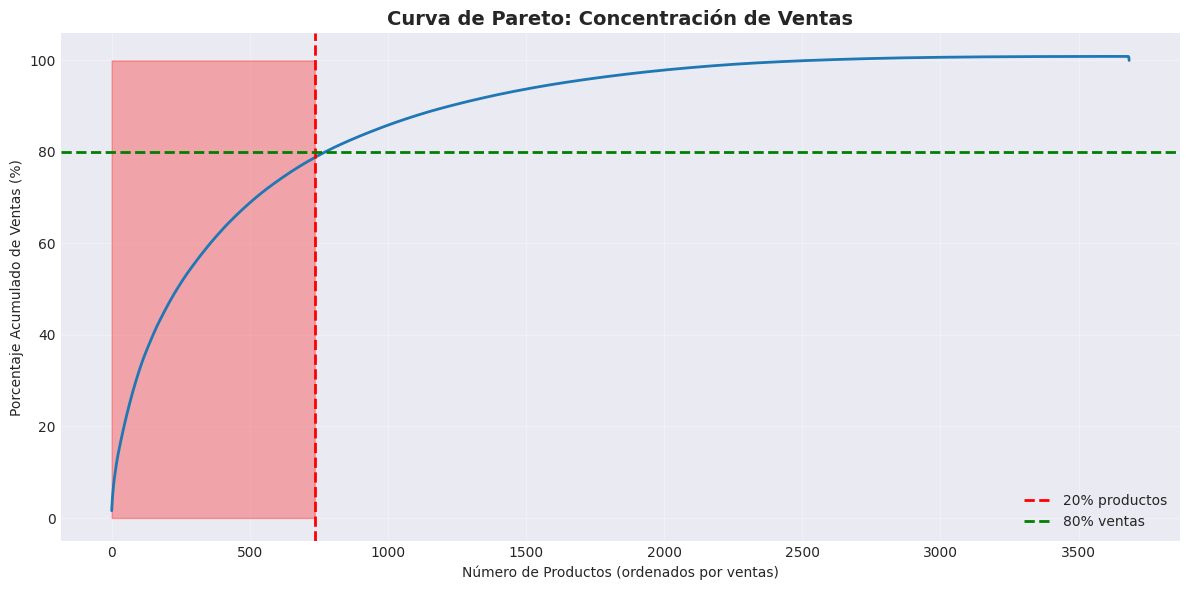

In [131]:
# Análisis de Pareto
productos_ventas = data_cleaned.groupby('StockCode')['Total_Amount'].sum().sort_values(ascending=False)
productos_ventas_cum = productos_ventas.cumsum()
total_ventas = productos_ventas.sum()
porcentaje_acumulado = (productos_ventas_cum / total_ventas) * 100

# Encontrar el 20% de productos
productos_20pct = int(len(productos_ventas) * 0.2)
ventas_20pct = porcentaje_acumulado.iloc[productos_20pct]

print(f"📊 ANÁLISIS DE PARETO:\n")
print(f"Total de productos únicos: {len(productos_ventas):,}")
print(f"20% de productos: {productos_20pct:,} productos")
print(f"Ventas generadas por el 20%: {ventas_20pct:.2f}%")
print(f"\n💡 Insight: ", end="")
if ventas_20pct >= 75:
    print(f"Se confirma el principio de Pareto. El 20% de productos genera ~{ventas_20pct:.0f}% de ventas.")
else:
    print(f"Las ventas están más distribuidas de lo esperado ({ventas_20pct:.0f}%).")

# Visualizar
plt.figure(figsize=(12, 6))
plt.plot(range(len(porcentaje_acumulado)), porcentaje_acumulado.values, linewidth=2)
plt.axvline(x=productos_20pct, color='red', linestyle='--', linewidth=2, label=f'20% productos')
plt.axhline(y=80, color='green', linestyle='--', linewidth=2, label='80% ventas')
plt.fill_between(range(productos_20pct), 0, 100, alpha=0.3, color='red')
plt.title('Curva de Pareto: Concentración de Ventas', fontsize=14, fontweight='bold')
plt.xlabel('Número de Productos (ordenados por ventas)')
plt.ylabel('Porcentaje Acumulado de Ventas (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9️⃣ FASE 9: Conclusiones y Próximos Pasos

### Resumen Ejecutivo del Proyecto

Este análisis completo demuestra el **flujo profesional de un científico de datos**:

✅ **Definición clara del problema**
✅ **Exploración exhaustiva de datos**
✅ **Limpieza documentada y justificada**
✅ **Feature Engineering estratégico**
✅ **Análisis exploratorio profundo**
✅ **Visualizaciones accionables**
✅ **Insights con recomendaciones**
✅ **Análisis adicionales de valor**

In [132]:
print("="*80)
print(" " * 25 + "📋 RESUMEN DEL PROYECTO")
print("="*80)

print("\n📊 ESTADÍSTICAS DEL DATASET:")
print(f"  - Filas originales: {len(retail_data):,}")
print(f"  - Filas después de limpieza: {len(data_cleaned):,}")
print(f"  - Porcentaje retenido: {(len(data_cleaned)/len(retail_data)*100):.2f}%")
print(f"  - Periodo analizado: {data_cleaned['InvoiceDate'].min()} a {data_cleaned['InvoiceDate'].max()}")
print(f"  - Total de clientes únicos: {data_cleaned['CustomerID'].nunique():,}")
print(f"  - Total de productos únicos: {data_cleaned['StockCode'].nunique():,}")
print(f"  - Ventas totales: ${data_cleaned['Total_Amount'].sum():,.2f}")

print("\n\n🎯 PREGUNTAS RESPONDIDAS:")
print("  ✅ ¿Cuáles son los productos más vendidos?")
print(f"     → Top 1: {top_productos.iloc[0]['Description']}")
print("  ✅ ¿Quiénes son los clientes más valiosos?")
print(f"     → Top cliente genera: ${top_clientes.iloc[0]['MonetaryValue']:,.2f}")
print("  ✅ ¿Hay patrones estacionales en las ventas?")
print(f"     → Sí, mes pico: {mes_max}, mes bajo: {mes_min}")
print("  ✅ ¿Cuál es el porcentaje de devoluciones?")
print(f"     → {pct_returns:.2f}%")
print("  ✅ ¿Cómo se distribuyen las ventas por categoría de monto?")
print(f"     → Categoría dominante: {categoria_dom} ({pct_dom:.1f}%)")

print("\n\n🚀 PRÓXIMOS PASOS RECOMENDADOS:")
print("  1. Implementar modelo predictivo de ventas (Machine Learning)")
print("  2. Crear sistema de recomendación de productos")
print("  3. Analizar cohorts de clientes por fecha de primera compra")
print("  4. Integrar datos de marketing para ROI de campañas")
print("  5. Automatizar este dashboard para reportes mensuales")
print("  6. Analizar geografía de clientes para expansión")

print("\n\n📚 HERRAMIENTAS UTILIZADAS:")
print("  • NumPy: Operaciones numéricas eficientes")
print("  • Pandas: Manipulación y análisis de datos")
print("  • Matplotlib: Visualizaciones profesionales")
print("  • GridSpec: Layouts complejos de dashboards")

print("\n\n💡 LECCIONES APRENDIDAS:")
print("  1. La limpieza de datos consume ~60% del tiempo (es normal)")
print("  2. Feature Engineering es clave para insights profundos")
print("  3. Las visualizaciones deben contar una historia")
print("  4. Los insights sin recomendaciones no tienen valor")
print("  5. Documentar decisiones es crucial para reproducibilidad")

print("\n" + "="*80)
print(" " * 20 + "🎓 PROYECTO COMPLETADO EXITOSAMENTE")
print("="*80)

                         📋 RESUMEN DEL PROYECTO

📊 ESTADÍSTICAS DEL DATASET:
  - Filas originales: 541,909
  - Filas después de limpieza: 401,604
  - Porcentaje retenido: 74.11%
  - Periodo analizado: 2010-12-01 08:26:00 a 2011-12-09 12:50:00
  - Total de clientes únicos: 4,372
  - Total de productos únicos: 3,684
  - Ventas totales: $8,278,519.42


🎯 PREGUNTAS RESPONDIDAS:
  ✅ ¿Cuáles son los productos más vendidos?
     → Top 1: PAPER CRAFT , LITTLE BIRDIE
  ✅ ¿Quiénes son los clientes más valiosos?
     → Top cliente genera: $279,489.02
  ✅ ¿Hay patrones estacionales en las ventas?
     → Sí, mes pico: 9, mes bajo: 11
  ✅ ¿Cuál es el porcentaje de devoluciones?
     → 2.21%
  ✅ ¿Cómo se distribuyen las ventas por categoría de monto?
     → Categoría dominante: Low (78.5%)


🚀 PRÓXIMOS PASOS RECOMENDADOS:
  1. Implementar modelo predictivo de ventas (Machine Learning)
  2. Crear sistema de recomendación de productos
  3. Analizar cohorts de clientes por fecha de primera compra
  4. I

## 🎓 Reflexión Final: Cómo Pensar Como un Científico de Datos

### Mindset Profesional

Este notebook te ha mostrado **mucho más que código**. Has aprendido a:

#### 1. **Hacer las preguntas correctas**
Antes de tocar datos, define:
- ¿Qué problema estoy resolviendo?
- ¿Quiénes son los stakeholders?
- ¿Qué decisiones se tomarán con mi análisis?

#### 2. **Ser escéptico con los datos**
- SIEMPRE explora antes de confiar
- Documenta problemas de calidad
- Justifica decisiones de limpieza

#### 3. **Crear valor, no solo gráficos**
- Un gráfico sin insights es decoración
- Traduce datos a lenguaje de negocio
- Proporciona recomendaciones accionables

#### 4. **Pensar en reproducibilidad**
- Documenta tu proceso
- Comenta decisiones técnicas
- Facilita que otros puedan replicar

#### 5. **Comunicar efectivamente**
- Stakeholders no técnicos necesitan visuales
- Gerentes necesitan números y ROI
- Técnicos necesitan código limpio

### Próxima Evolución

Este proyecto es una **base sólida**. Para convertirte en un científico de datos senior:

- **Aprende Machine Learning:** Modelos predictivos (sklearn, TensorFlow)
- **Domina SQL:** Trabaja con bases de datos reales
- **Automatiza:** Aprende a crear pipelines (Airflow, Luigi)
- **Visualiza mejor:** Dashboards interactivos (Plotly, Dash, Tableau)
- **Escala:** Big Data con PySpark

### Recuerda

> "Un científico de datos es un contador de historias armado con datos."
> — DJ Patil, ex Chief Data Scientist de EE.UU.

**Tu misión:** Convertir datos en decisiones, números en narrativas, y análisis en acciones.

---

**¡Felicitaciones! Has completado un análisis de datos de nivel profesional.** 🎉

---

**Actualizado:** 21 de octubre de 2025
**Progreso de la ruta:** 42% completado (8/19 cursos)
**Proyecto:** Análisis Completo de Retail Online
**Tiempo invertido:** ~4 horas de análisis profesional

**Conexión con Proyecto Final:**
Este flujo completo es la base para tu "Customer Experience Analyzer". Aplicarás:
- Limpieza de encuestas CSAT
- Feature Engineering de satisfacción
- Dashboards ejecutivos
- Insights accionables para mejorar CX

---

**📁 Archivos Relacionados:**
- `25_Analisis_datos_portafolio_final.ipynb` - Este notebook
- `data_loader.py` - Utilidad de carga de datos
- `online_retail.csv` - Dataset analizado

**📚 Recursos Adicionales:**
- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [Matplotlib Gallery](https://matplotlib.org/stable/gallery/index.html)
- [Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/)